In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

from google.colab import drive
drive.mount("/content/drive")


%cd /content/drive/MyDrive/Python_Analytics/CSV




Mounted at /content/drive
/content/drive/MyDrive/Python_Analytics/CSV


In [ ]:
import os
os.listdir()


['Netflix_titles.csv',
 'sales_data.csv',
 'adult.csv',
 'tips.csv',
 'sales_data_updated.csv',
 'dataset.zip',
 'dataset']

#Вступ

У цьому проєкті виконано аналіз продажів на основі набору даних із трьох таблиць: events.csv, countries.csv та products.csv. Мета роботи — підготувати дані до аналізу та отримати зрозумілі бізнес-висновки щодо продажів: оцінити виручку, витрати та прибуток, визначити найпопулярніші категорії товарів, а також порівняти результати в розрізі каналів продажу (Online/Offline), країн і регіонів.
Джерелом даних є архів dataset.zip, з якого були завантажені CSV-файли. Основна фактова таблиця events містить інформацію про замовлення (дати, канал продажів, країна, продукт, кількість, ціна та собівартість), а таблиці countries і products використовуються як довідники для розшифрування географії та категорій товарів.
Структура звіту побудована за логікою повного аналітичного процесу:
Огляд даних — опис таблиць, їхніх полів та ключів для об’єднання.


Очищення та підготовка даних — перевірка пропусків, дублікатів, типів даних і коректності значень.


Аналітична частина — розрахунок ключових метрик (Revenue/Cost/Profit), аналіз у розрізі каналів, країн/регіонів і категорій товарів, а також візуалізації для підтвердження висновків.


Підсумки — узагальнення результатів та короткі рекомендації на основі отриманих закономірностей.


#**1.Data overview**

In [ ]:
import zipfile

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")


In [ ]:
os.listdir("dataset")


['13. Final project']

In [ ]:
os.listdir("dataset/13. Final project")


['countries.csv', 'products.csv', 'events.csv']

In [ ]:
import glob
import os
import pandas as pd

csv_files = glob.glob("dataset/13. Final project/*.csv")
csv_files


['dataset/13. Final project/countries.csv',
 'dataset/13. Final project/products.csv',
 'dataset/13. Final project/events.csv']

In [ ]:
countries = pd.read_csv("dataset/13. Final project/countries.csv")
events = pd.read_csv("dataset/13. Final project/events.csv")
products = pd.read_csv("dataset/13. Final project/products.csv")

In [ ]:
countries.shape, events.shape, products.shape


((249, 5), (1330, 10), (12, 2))

In [ ]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
print(countries)

                  name alpha-2 alpha-3   region          sub-region
0          Afghanistan      AF     AFG     Asia       Southern Asia
1        Åland Islands      AX     ALA   Europe     Northern Europe
2              Albania      AL     ALB   Europe     Southern Europe
3              Algeria      DZ     DZA   Africa     Northern Africa
4       American Samoa      AS     ASM  Oceania           Polynesia
..                 ...     ...     ...      ...                 ...
244  Wallis and Futuna      WF     WLF  Oceania           Polynesia
245     Western Sahara      EH     ESH   Africa     Northern Africa
246              Yemen      YE     YEM     Asia        Western Asia
247             Zambia      ZM     ZMB   Africa  Sub-Saharan Africa
248           Zimbabwe      ZW     ZWE   Africa  Sub-Saharan Africa

[249 rows x 5 columns]


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
print(events)

       Order ID Order Date   Ship Date Order Priority Country Code  \
0     100640618  10/8/2014  10/18/2014              M          NOR   
1     100983083  8/11/2016   8/11/2016              C          SRB   
2     101025998  7/18/2014   8/11/2014              M          NaN   
3     102230632  5/13/2017   6/13/2017              L          MNE   
4     103435266  8/11/2012   9/18/2012              H          SRB   
...         ...        ...         ...            ...          ...   
1325  994504153  1/10/2017   1/13/2017              M          SWE   
1326  994978797  12/5/2014    1/2/2015              H          ITA   
1327  996754205  9/20/2010   9/22/2010              L          RUS   
1328  998043382  6/15/2010    7/3/2010              H          MLT   
1329  999879729  3/31/2012    5/6/2012              M          ALB   

      Product ID Sales Channel  Units Sold  Unit Price  Unit Cost  
0           2103        Online       650.0      205.70     117.11  
1           2103       

In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
print(products)

      id        item_type
0   2103           Cereal
1   7940        Household
2   2455          Clothes
3   1270        Beverages
4   8681  Office Supplies
5   4594           Fruits
6   5988       Vegetables
7   7331        Baby Food
8   8875             Meat
9   8293        Cosmetics
10  8969           Snacks
11  3127    Personal Care


#Оляд даних
Завантаження даних
Для аналізу були завантажені три CSV-файли з архіву dataset.zip: events.csv, products.csv, countries.csv.
Огляд таблиць
1) countries.csv — довідник країн
Розмір: 249 рядків × 5 стовпців

Поля:
* name — назва країни
* alpha-2 — 2-буквений код країни
* alpha-3 — 3-буквений код країни
* region — великий регіон
* sub-region — підрегіон

Призначення: географічна класифікація для подальшої агрегації продажів за регіонами/країнами.


2) events.csv — транзакції/замовлення (фактова таблиця)
Розмір: 1330 рядків × 10 стовпців

Поля:
* Order ID — унікальний номер замовлення
* Order Date — дата створення замовлення
* Ship Date — дата відправки/доставки
* Order Priority — пріоритет
* Country Code — код країни
* Product ID — ідентифікатор продукту
* Sales Channel — канал продажів
* Units Sold — кількість проданих одиниць
* Unit Price — ціна за 1 одиницю
* Unit Cost — собівартість за 1 одиницю


Призначення: основне джерело для розрахунку виручки/витрат/прибутку та аналізу продажів у розрізі часу, каналу, країни та продукту.


3) products.csv — довідник продуктів
Розмір: 12 рядків × 2 стовпці


Поля:
* id — ідентифікатор продукту
* item_type — тип товару


Призначення: категоризація транзакцій для аналізу популярності та фінансових показників за типами товарів.


Ключові поля для з’єднання таблиць
events.Country Code ↔ countries.alpha-3 (зв’язок по 3-літерному коду країни)


events.Product ID ↔ products.id (зв’язок по ідентифікатору продукту)


Висновки щодо структури даних
Набір даних має класичну аналітичну структуру: events виступає як фактова таблиця з показниками продажів (Units Sold, Unit Price, Unit Cost) та описовими атрибутами (дати, канал, країна, продукт), а countries і products — як довідники для збагачення даних і побудови зрізів (регіони/підрегіони та категорії товарів). Така модель дозволяє коректно виконувати агрегації й порівняння за країнами, регіонами, категоріями, каналами продажів і часовими періодами.





# **2.Data cleaning**

# Перевірка Таблиці countries

**Робимо перевірку пропусків:**

In [ ]:


countries.isna().sum()

,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1


In [ ]:

print(countries.isna().sum() / countries.shape[0] * 100)


name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


In [ ]:
countries[countries["region"].isna()]


,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN


In [ ]:
countries["region"] = countries["region"].fillna("No region")
countries["sub-region"] = countries["sub-region"].fillna("No sub-region")


У таблиці countries виявлено пропуски в колонках region та sub-region для країни Antarctica. Це є очікуваним, оскільки Антарктида не належить до жодного географічного регіону.Щоб уникнути помилок при групуванні,було замінено NaN на "No region" та "No sub-region".

In [ ]:
countries[countries["alpha-2"].isna()]

,name,alpha-2,alpha-3,region,sub-region
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


In [ ]:
countries.loc[
    (countries["alpha-3"] == "NAM") & (countries["alpha-2"].isna()),
    "alpha-2"
] = "NA"


In [ ]:
countries[countries["alpha-3"] == "NAM"]


,name,alpha-2,alpha-3,region,sub-region
153,Namibia,NA,NAM,Africa,Sub-Saharan Africa


Пропуск у полі alpha-2 для Namibia був заповнений умовно на основі відповідного alpha-3 коду (NAM), використовуючи стандарт ISO 3166-1.

In [ ]:
countries.isna().sum()

,0
name,0
alpha-2,0
alpha-3,0
region,0
sub-region,0


**Перевірка дублікатів:**

In [ ]:

duplicate_rows = countries.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())


0      False
1      False
2      False
3      False
4      False
       ...  
244    False
245    False
246    False
247    False
248    False
Length: 249, dtype: bool
0


**Додаткова перевірка ключових стовпців:**

In [ ]:
duplicate_alpha_2 = countries["alpha-2"].duplicated()
print(duplicate_alpha_2)
print(duplicate_alpha_2.sum())

0      False
1      False
2      False
3      False
4      False
       ...  
244    False
245    False
246    False
247    False
248    False
Name: alpha-2, Length: 249, dtype: bool
0


In [ ]:
duplicate_alpha_3 = countries["alpha-2"].duplicated()
print(duplicate_alpha_3)
print(duplicate_alpha_3.sum())

0      False
1      False
2      False
3      False
4      False
       ...  
244    False
245    False
246    False
247    False
248    False
Name: alpha-2, Length: 249, dtype: bool
0


Повні дублікати рядків у таблиці countries відсутні. Також перевірено унікальність кодів країн (alpha-2 та alpha-3), які використовуються як ключі. Дублікатів не виявлено.

**Перевірка на "?"," ","Unknown":**

In [ ]:
countries.isin(["?"]).sum()


,0
name,0
alpha-2,0
alpha-3,0
region,0
sub-region,0


In [ ]:
countries.isin(["Unknown"]).sum()

,0
name,0
alpha-2,0
alpha-3,0
region,0
sub-region,0


In [ ]:
countries.isin([""]).sum()

,0
name,0
alpha-2,0
alpha-3,0
region,0
sub-region,0


Виконано глобальну перевірку на наявність некоректних текстових значень ("?", порожні рядки, "Unknown") та дублікатів. За результатами перевірки такі значення не виявлені.

**Перевірка ключових стовпців на кількість літер:**

In [ ]:
countries[countries["alpha-2"].str.len() != 2]


,name,alpha-2,alpha-3,region,sub-region


In [ ]:
countries[countries["alpha-3"].str.len() != 3]


,name,alpha-2,alpha-3,region,sub-region


# Перевірка Таблиці events

**Перевірка пропусків:**

In [ ]:
events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


**Додаткова перевірка ключових стовпців:**

In [ ]:
events[events["Country Code"].isna()]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
13,104548490,1/1/2014,1/5/2014,M,NaN,7331,Online,7076.0,255.28,159.42
26,117929494,1/24/2015,3/2/2015,H,NaN,4594,Offline,6813.0,9.33,6.92
29,118859469,6/2/2011,7/1/2011,L,NaN,8969,Offline,2013.0,152.58,97.44
43,126948583,5/24/2017,7/9/2017,C,NaN,7331,Online,5762.0,255.28,159.42
...,...,...,...,...,...,...,...,...,...,...
1213,919922006,8/27/2011,9/18/2011,L,NaN,4594,Online,4219.0,9.33,6.92
1220,922564303,3/17/2017,4/2/2017,L,NaN,7940,Offline,6134.0,668.27,502.54
1250,941061675,3/8/2017,3/20/2017,M,NaN,5988,Offline,9917.0,154.06,90.93
1296,975080668,7/23/2017,8/20/2017,C,NaN,5988,Offline,6893.0,154.06,90.93


У таблиці events виявлено 82 записи з відсутнім значенням у полі Country Code, яке використовується для зʼєднання з таблицею countries. Ці записи становлять близько 6% даних. Оскільки відсутні значення не можуть бути коректно відновлені, вони були збережені як пропуски. При подальшому аналізі буде використаний LEFT JOIN, що дозволить зберегти всі замовлення, навіть без інформації про країну.

In [ ]:
events = events[events["Units Sold"].notna()]
events[events["Units Sold"].isna()]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


У колонці Units Sold виявлено 2 записи з відсутніми значеннями. Оскільки ця змінна є ключовою для розрахунку продажів і частка пропусків є незначною (<1%), відповідні рядки були видалені з подальшого аналізу.

In [ ]:
events.isna().sum()


,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


**Перевірка на "?"," ","Unknown":**

In [ ]:
events.isin(["?"]).sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [ ]:
events.isin([""]).sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [ ]:
events.isin(["Unknown"]).sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


**Перевірка дублікатів:**

In [ ]:
duplicate_rows = events.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0       False
1       False
2       False
3       False
4       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1328, dtype: bool
0


In [ ]:
duplicate_id = events.duplicated(subset=["Order ID", "Product ID"])
print(duplicate_id.sum())


0


Виконано глобальну перевірку на наявність некоректних текстових значень ("?", порожні рядки, "Unknown") та дублікатів. За результатами перевірки такі значення не виявлені.

In [ ]:
events["Order Date"] = pd.to_datetime(events["Order Date"])
events['Order Date']

,Order Date
0,2014-10-08
1,2016-08-11
2,2014-07-18
3,2017-05-13
4,2012-08-11
...,...
1325,2017-01-10
1326,2014-12-05
1327,2010-09-20
1328,2010-06-15


In [ ]:
events["Ship Date"] = pd.to_datetime(events["Ship Date"])
events["Ship Date"]

,Ship Date
0,2014-10-18
1,2016-08-11
2,2014-08-11
3,2017-06-13
4,2012-09-18
...,...
1325,2017-01-13
1326,2015-01-02
1327,2010-09-22
1328,2010-07-03


Виконано приведення колонок Order Date та Ship Date до формату datetime для коректного аналізу часових залежностей та розрахунку тривалості доставки.

**Перевірка на зайві пробіли на початку або в кінці значень у колонці Sales Channel:**

In [ ]:
events["Sales Channel"] != events["Sales Channel"].str.strip()


,Sales Channel
0,False
1,False
2,False
3,False
4,False
...,...
1325,False
1326,False
1327,False
1328,False


**Перевірка на кількість унікальних значень в колонці(value_counts()):**

In [ ]:
events["Sales Channel"].value_counts()

,count
Sales Channel,
Offline,665
Online,660
online,3


Маємо одне значення,яке написано літерами різної величини.

Переводимо всі літери в ніжній регістр:

In [ ]:
events["Sales Channel"] = events["Sales Channel"].str.lower()


In [ ]:
events["Sales Channel"].value_counts()

,count
Sales Channel,
offline,665
online,663


Колонка "Order Priority" показує одну велику літеру,робимо,щоб не було зайвих пробілів(до та після) й переводимо до верхнього регістру:

In [ ]:
events["Order Priority"] = (
    events["Order Priority"]
    .str.strip()
    .str.upper()
)



In [ ]:
events["Order Priority"].value_counts()

,count
Order Priority,
M,353
H,335
L,334
C,306


Переводимо до верхнього регістру всі значення ключової колонки (.upper()):

In [ ]:
events["Country Code"] != events["Country Code"].str.upper()

,Country Code
0,False
1,False
2,True
3,False
4,False
...,...
1325,False
1326,False
1327,False
1328,False


Перевірка на зайві пропуски:

In [ ]:
events[events["Country Code"] != events["Country Code"].str.upper()]


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
2,101025998,2014-07-18,2014-08-11,M,NaN,7940,online,4693.0,668.27,502.54
13,104548490,2014-01-01,2014-01-05,M,NaN,7331,online,7076.0,255.28,159.42
26,117929494,2015-01-24,2015-03-02,H,NaN,4594,offline,6813.0,9.33,6.92
29,118859469,2011-06-02,2011-07-01,L,NaN,8969,offline,2013.0,152.58,97.44
43,126948583,2017-05-24,2017-07-09,C,NaN,7331,online,5762.0,255.28,159.42
...,...,...,...,...,...,...,...,...,...,...
1213,919922006,2011-08-27,2011-09-18,L,NaN,4594,online,4219.0,9.33,6.92
1220,922564303,2017-03-17,2017-04-02,L,NaN,7940,offline,6134.0,668.27,502.54
1250,941061675,2017-03-08,2017-03-20,M,NaN,5988,offline,9917.0,154.06,90.93
1296,975080668,2017-07-23,2017-08-20,C,NaN,5988,offline,6893.0,154.06,90.93


У колонці Country Code виявлено 82  значення,які не відповідають верхньому регістру. Виявлені значення відповідають пропущеним (NaN) даним, які були ідентифіковані раніше. Інших некоректних значень не знайдено.

Перевірка значень числової колонки Units Sold (.describe()):

In [ ]:
events["Units Sold"].describe()

,Units Sold
count,1328.000000
mean,4952.201807
std,2905.198996
min,2.000000
25%,2356.750000
50%,4962.000000
75%,7459.500000
max,9999.000000


Аномалій у колонці Units Sold не виявлено.

Перевірка на коректність даних:

In [ ]:
events[events["Unit Price"] < events["Unit Cost"]]


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


Розрахунок і додавання колонки "margin",яка відображає різницю між ціною продажу та собівартістю одиниці товару:

In [ ]:
events["margin"] = events["Unit Price"] - events["Unit Cost"]
events["margin"].describe()



,margin
count,1328.000000
mean,77.701724
std,52.706372
min,2.410000
25%,25.060000
50%,63.130000
75%,126.250000
max,173.870000


Перевірка співвідношення Unit Price та Unit Cost показала, що ціна продажу не нижча за собівартість у всіх спостереженнях. Порушень бізнес-логіки не виявлено.

In [ ]:
events["Order Date"].info()

<class 'pandas.core.series.Series'>
Index: 1328 entries, 0 to 1329
Series name: Order Date
Non-Null Count  Dtype         
--------------  -----         
1328 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 20.8 KB


In [ ]:
events["Ship Date"].info()

<class 'pandas.core.series.Series'>
Index: 1328 entries, 0 to 1329
Series name: Ship Date
Non-Null Count  Dtype         
--------------  -----         
1328 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 20.8 KB


Розрахунок,додавання та перевірка стовпця "delivery_days":

In [ ]:
events["delivery_days"] = (events["Ship Date"] - events["Order Date"]).dt.days


In [ ]:
events[events["delivery_days"] < 0]


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,margin,delivery_days


In [ ]:
events["delivery_days"].describe()


,delivery_days
count,1328.000000
mean,24.786898
std,14.586041
min,0.000000
25%,12.000000
50%,25.000000
75%,37.000000
max,50.000000


Було розраховано тривалість доставки (delivery_days) як різницю між датами Ship Date та Order Date. Перевірка не виявила від’ємних значень, що підтверджує логічну коректність дат. Максимальна тривалість доставки становить 50 днів, що не виходить за межі розумного інтервалу.

# Перевірка Таблиці products

Перевірка на пробіли,дублікати та не коректні дані;

In [ ]:
products.isna().sum()

,0
id,0
item_type,0


In [ ]:
products.isin(["?"]).sum()

,0
id,0
item_type,0


In [ ]:
products.isin([""]).sum()

,0
id,0
item_type,0


In [ ]:
products.isin(["Unknown"]).sum()

,0
id,0
item_type,0


In [ ]:
duplicate_rows = products.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype: bool
0


In [ ]:
duplicate_id = products.duplicated(subset=["id", "item_type"])
print(duplicate_id.sum())

0


In [ ]:
products["item_type"] != products["item_type"].str.strip()

,item_type
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [ ]:
products["item_type"] != products["item_type"].str.lower()

,item_type
0,True
1,True
2,True
3,True
4,True
5,True
6,True
7,True
8,True
9,True


Таблиця products є довідниковою та використовується для об’єднання з таблицею events. Було перевірено наявність пропущених значень, некоректних текстових значень та дублікатів. Пропущених значень і дублікатів не виявлено, ключове поле id є унікальним.Також було перевірено консистентність регістру в полі item_type. Усі значення мають однаковий формат написання, структурних дублікатів через різний регістр не виявлено. Таблиця готова до подальшого аналізу та об’єднання.

# **3.Data analysis and visualization**.

# Об'єднання таблиць


In [ ]:
events_countries = events.merge(
    countries,
    how="left",
    left_on="Country Code",
    right_on="alpha-3"
)



In [ ]:
events_countries["name"].isna().sum()

np.int64(82)

In [ ]:
events_countries.shape

(1328, 17)

Таблиця events була об’єднана з довідниковою таблицею countries за кодом країни (Country Code та alpha-3) з використанням LEFT JOIN, що дозволило зберегти всі записи замовлень.

In [ ]:
sales_data = events_countries.merge(
    products,
    how="left",
    left_on="Product ID",
    right_on="id"

)

In [ ]:
sales_data["item_type"].isna().sum()


np.int64(0)

In [ ]:
sales_data.shape

(1328, 19)

Таблиця events була об’єднана з довідниковою таблицею countries за кодом країни (Country Code та alpha-3) з використанням LEFT JOIN, що дозволило зберегти всі записи замовлень.

In [ ]:
print(sales_data)

       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0     100640618 2014-10-08 2014-10-18              M          NOR        2103   
1     100983083 2016-08-11 2016-08-11              C          SRB        2103   
2     101025998 2014-07-18 2014-08-11              M          NaN        7940   
3     102230632 2017-05-13 2017-06-13              L          MNE        2455   
4     103435266 2012-08-11 2012-09-18              H          SRB        1270   
...         ...        ...        ...            ...          ...         ...   
1323  994504153 2017-01-10 2017-01-13              M          SWE        4594   
1324  994978797 2014-12-05 2015-01-02              H          ITA        1270   
1325  996754205 2010-09-20 2010-09-22              L          RUS        7331   
1326  998043382 2010-06-15 2010-07-03              H          MLT        8293   
1327  999879729 2012-03-31 2012-05-06              M          ALB        7940   

     Sales Channel  Units S


Для контролю коректності з’єднання таблиць було використано індикатор _merge, який показав, що більшість записів успішно поєдналися, а частина рядків не має відповідника через відсутні значення коду країни.
Після об’єднання таблиць фінальний датафрейм sales_data містить 1328 рядків та 19 колонок, що відповідає очікуваній кількості записів продажів.

Розрахунок та додавання колонки "profit",яка є важливою для подальшого аналізу даних:

In [ ]:
sales_data["profit"] = (
    (sales_data["Unit Price"] - sales_data["Unit Cost"])
    * sales_data["Units Sold"]
)


In [ ]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
 10  margin          1328 non-null   float64       
 11  delivery_days   1328 non-null   int64         
 12  name            1246 non-null   object        
 13  alpha-2         1246 non-null   object        
 14  alpha-3         1246 non-null   object        
 15  regi

Видалення непотрібних для аналізу колонок:

In [ ]:
sales_data = sales_data.drop(
    columns=[
        "Product ID",
        "id",
        "alpha-2",
        "alpha-3",
        "Country Code",
        "Ship Date",
        "Unit Price",
        "Unit Cost"

    ]
)


Після об’єднання таблиць було виконано очищення фінального датасету.
Технічні ідентифікатори (Product ID, id, Country Code) та довідкові коди (alpha-2, alpha-3), які використовувалися лише для з’єднання таблиць, були видалені.

Колонки Unit Price та Unit Cost також були виключені, оскільки на їх основі вже розраховано узагальнені показники margin та profit, які є більш інформативними для подальшого аналізу.

Колонка Ship Date була видалена після розрахунку delivery_days, оскільки дата доставки надалі не буде використовуватись.

Це дозволило зменшити розмір датасету та залишити лише релевантні для аналізу бізнес-показники.

**Перевірка даних після об’єднання таблиць:**

In [ ]:
sales_data.isna().sum()


,0
Order ID,0
Order Date,0
Order Priority,0
Sales Channel,0
Units Sold,0
margin,0
delivery_days,0
name,82
region,82
sub-region,82


In [ ]:
duplicate_rows = sales_data.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0       False
1       False
2       False
3       False
4       False
        ...  
1323    False
1324    False
1325    False
1326    False
1327    False
Length: 1328, dtype: bool
0


In [ ]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Order Priority  1328 non-null   object        
 3   Sales Channel   1328 non-null   object        
 4   Units Sold      1328 non-null   float64       
 5   margin          1328 non-null   float64       
 6   delivery_days   1328 non-null   int64         
 7   name            1246 non-null   object        
 8   region          1246 non-null   object        
 9   sub-region      1246 non-null   object        
 10  item_type       1328 non-null   object        
 11  profit          1328 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(6)
memory usage: 124.6+ KB


**Переіменування колонок:**

In [ ]:
sales_data = sales_data.rename(
    columns={
        "name": "country",
        "item_type": "category"
    }
)



Перевірка назв колонок на пропуски,зайві знаки та приведення всіх літер до ніжнього регістру:

In [ ]:
sales_data.columns = sales_data.columns.str.lower().str.replace("_"," ")


In [ ]:
print(sales_data)

       order id order date order priority sales channel  units sold  margin  \
0     100640618 2014-10-08              M        online       650.0   88.59   
1     100983083 2016-08-11              C       offline      1993.0   88.59   
2     101025998 2014-07-18              M        online      4693.0  165.73   
3     102230632 2017-05-13              L        online      1171.0   73.44   
4     103435266 2012-08-11              H       offline      7648.0   15.66   
...         ...        ...            ...           ...         ...     ...   
1323  994504153 2017-01-10              M        online      4734.0    2.41   
1324  994978797 2014-12-05              H       offline      5192.0   15.66   
1325  996754205 2010-09-20              L       offline       574.0   95.86   
1326  998043382 2010-06-15              H        online      2070.0  173.87   
1327  999879729 2012-03-31              M       offline      5486.0  165.73   

      delivery days     country  region       sub-r

**Розрахунки метрик та аналіз:**

In [ ]:
total_orders = sales_data["order id"].nunique()
total_orders

1328

In [ ]:
total_profit = sales_data["profit"].sum()
total_profit

np.float64(501434459.0)

In [ ]:
avg_profit_per_order = sales_data["profit"].mean()
avg_profit_per_order

np.float64(377586.1890060241)

In [ ]:
total_units_sold = sales_data["units sold"].sum()
total_units_sold

np.float64(6576524.0)

In [ ]:
avg_margin = sales_data["margin"].mean()
avg_margin

np.float64(77.70172439759035)

In [ ]:
countries_count = sales_data["country"].nunique(dropna=True)
countries_count

45

In [ ]:
sub_regions_count = sales_data["sub-region"].nunique(dropna=True)
sub_regions_count

5

In [ ]:
regions_count = sales_data["region"].nunique(dropna=True)
regions_count

2

In [ ]:
categories_count = sales_data["category"].nunique()
categories_count

12

In [ ]:
orders_by_channel = sales_data["sales channel"].value_counts()
orders_by_channel


,count
sales channel,
offline,665
online,663


In [ ]:
orders_by_priority = sales_data['order priority'].value_counts()
orders_by_priority


,count
order priority,
M,353
H,335
L,334
C,306


Було проаналізовано загальну кількість замовлень, сумарний та середній прибуток, обсяг проданих одиниць, географічне покриття та логістичні показники.
Ці метрики дозволяють сформувати загальне уявлення про масштаб бізнесу, його фінансову ефективність та операційні характеристики.

**Продажі в розрізі категорій товарів:**

Загальний прибуток по категоріях:

In [ ]:
profit_by_categories = sales_data.groupby("category", as_index=False)["profit"].sum().sort_values(by="profit", ascending=False)
profit_by_categories

,category,profit
4,Cosmetics,92723306.17
8,Office Supplies,77977176.25
6,Household,72962466.77
0,Baby Food,53940997.16
3,Clothes,43431314.40
2,Cereal,41255034.15
11,Vegetables,36776002.72
7,Meat,30337736.00
10,Snacks,27027422.40
9,Personal Care,13975410.68


Загальна кількість проданих одиниць по категоріях:

In [ ]:
total_units_sold_by_category = sales_data.groupby("category", as_index=False)["units sold"].sum().sort_values(by="units sold", ascending=False)
total_units_sold_by_category


,category,units sold
8,Office Supplies,617641.0
1,Beverages,613133.0
5,Fruits,591672.0
3,Clothes,591385.0
11,Vegetables,582544.0
0,Baby Food,562706.0
9,Personal Care,557678.0
4,Cosmetics,533291.0
7,Meat,530380.0
10,Snacks,490160.0


Середній прибуток по кожному замовленню в розрізі товарних категорій:

In [ ]:
avg_profit_per_order_by_category = sales_data.groupby(["category", "order id"])["profit"].mean()
avg_profit_per_order_by_category


category    order id 
Baby Food   103832662    502977.42
            104548490    678305.36
            108407437    865136.50
            111063039    467413.36
            111893022     46587.96
                           ...    
Vegetables  969195258    332631.97
            972452533    578838.97
            975080668    435155.09
            987050187    564382.20
            992992675    470571.02
Name: profit, Length: 1328, dtype: float64

Відсоток прибутка по категоріях:

In [ ]:
part_of_the_profit_percent = (sales_data.groupby("category")["profit"].sum() / total_profit * 100)
part_of_the_profit_percent


,profit
category,
Baby Food,10.757338
Beverages,1.914839
Cereal,8.227403
Clothes,8.661414
Cosmetics,18.491610
Fruits,0.284370
Household,14.550748
Meat,6.050190
Office Supplies,15.550821


Побудування стовпчастої діаграми(Bar Chart) для візуалізації загального прибутка по категоріях:

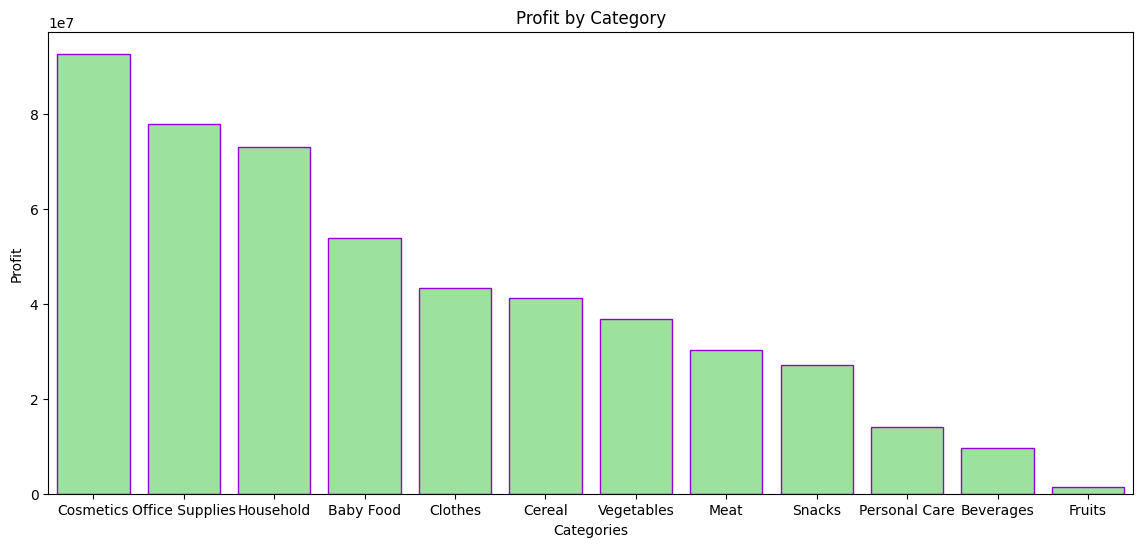

In [ ]:
plt.figure(figsize=(14, 6))
profit_by_category = (
    sales_data
    .groupby("category", as_index=False)["profit"]
    .sum()
    .sort_values("profit", ascending=False)
)

sns.barplot(
    data=profit_by_category,
    x="category",
    y="profit",
    color="lightgreen",
    edgecolor="darkviolet"
)
plt.title("Profit by Category")
plt.xlabel("Categories")
plt.ylabel("Profit")
plt.show()


Горизонтальна стовпчаста діаграма відображає обсяг продажів (кількість проданих одиниць) у кожній товарній категорії.

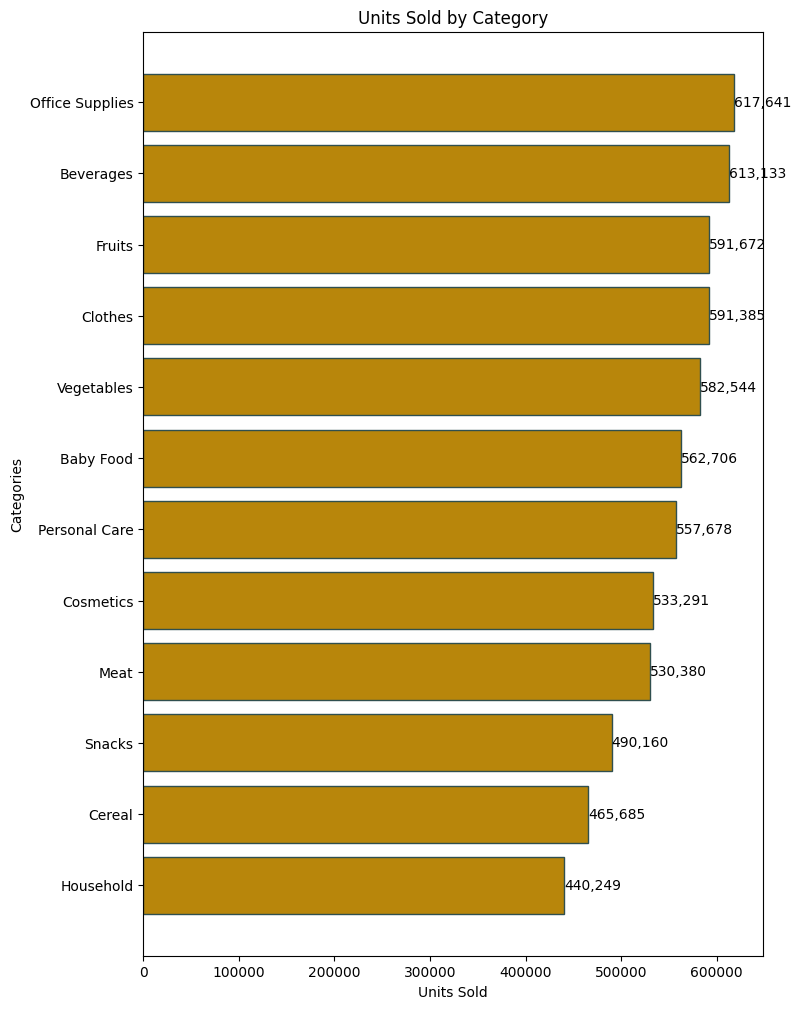

In [ ]:
plt.figure(figsize=(8, 12))
total_units_sold_by_category = sales_data.groupby(
    "category", as_index=False)["units sold"].sum().sort_values(by="units sold", ascending=False)

plt.barh(
    total_units_sold_by_category["category"],
    total_units_sold_by_category["units sold"],
    color="darkgoldenrod",
    edgecolor="darkslategray"
)
plt.gca().invert_yaxis()
for index, value in enumerate(total_units_sold_by_category["units sold"]):
    plt.text(value, index, f"{value:,.0f}", va="center")


plt.title("Units Sold by Category")
plt.xlabel("Units Sold")
plt.ylabel("Categories")
plt.show()

Точкова діаграма (scatter plot), яка показує зв’язок між кількістю проданих одиниць і прибутком для кожного рядка у sales_data:

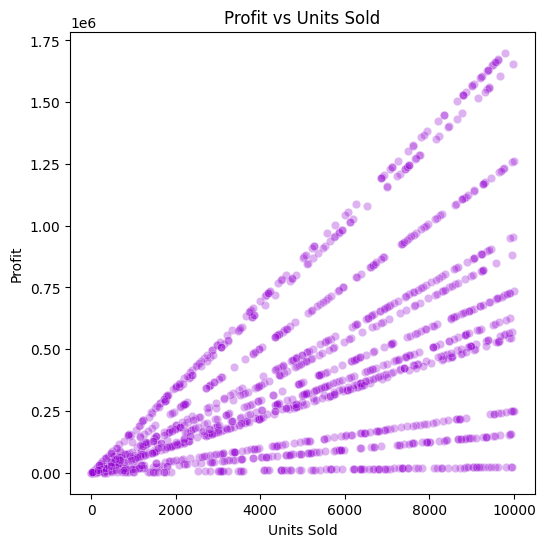

In [ ]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=sales_data,
    x="units sold",
    y="profit",
    color="darkviolet",
    alpha=0.3
)

plt.title("Profit vs Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Profit")
plt.show()


Найбільший прибуток формують категорії Cosmetics, Office Supplies та Household.
Саме ці категорії є ключовими драйверами прибутковості компанії, навіть якщо вони не завжди входять до топу за обсягом проданих одиниць.
 Популярність товарів (Units Sold) не завжди корелює з прибутковістю.
Наприклад, категорії Beverages та Fruits мають високі обсяги продажів, проте генерують відносно низький прибуток, що може свідчити про низьку маржинальність або високу собівартість.
 Діаграма “Profit vs Units Sold” показує позитивну залежність між кількістю проданих одиниць та прибутком, однак з великою варіативністю.
Це означає, що при однакових обсягах продажів різні категорії можуть приносити суттєво різний прибуток, що підкреслює важливість аналізу маржі, а не лише обсягів.

**Продажі в розрізі географії (країн, регіонів):**

Загальний прибуток по країнах:

In [ ]:
total_profit_by_country = sales_data.groupby("country")["profit"].sum().sort_values(ascending=False)
total_profit_by_country

,profit
country,
Andorra,15410036.63
Ukraine,14804925.74
Malta,14610127.88
San Marino,13792992.81
Hungary,13786231.03
Macedonia,13684099.95
Czech Republic,13635593.78
Russia,13267682.64
Bosnia and Herzegovina,13257602.77


Загальна кількість проданих одниниць по країнах:

In [ ]:
total_units_sold_by_country = sales_data.groupby("country")["units sold"].sum().sort_values(ascending=False)
total_units_sold_by_country

,units sold
country,
Macedonia,203078.0
San Marino,192228.0
Andorra,185686.0
Greece,176859.0
Malta,173641.0
Serbia,170369.0
Romania,166882.0
Russia,165954.0
Ukraine,164577.0


Кількість замовлень по країнах:

In [ ]:
orders_count_by_country = sales_data.groupby("country")["order id"].nunique().sort_values(ascending=False)
orders_count_by_country

,order id
country,
Andorra,40
San Marino,40
Romania,34
Bosnia and Herzegovina,33
Ukraine,33
Greece,32
Macedonia,32
Malta,32
Russia,32


Середній прибуток з одного замовлення для кожної країни:


In [ ]:
avg_profit_per_order_by_country = sales_data.groupby("country")["profit"].mean()
avg_profit_per_order_by_country

,profit
country,
Albania,499557.429524
Andorra,385250.915750
Armenia,324908.730345
Austria,358125.344286
Belarus,423300.751786
Belgium,287540.774615
Bosnia and Herzegovina,401745.538485
Bulgaria,346944.753667
Croatia,430484.085294


Середній час доставки замовлення по кожній країні:

In [ ]:
avg_dalivery_days_by_country = sales_data.groupby("country")["delivery days"].mean()
avg_dalivery_days_by_country

,delivery days
country,
Albania,26.190476
Andorra,26.275000
Armenia,26.172414
Austria,28.500000
Belarus,25.250000
Belgium,26.538462
Bosnia and Herzegovina,26.060606
Bulgaria,26.800000
Croatia,18.352941


Загальний прибуток для кожного регіона:

In [ ]:
total_profit_by_region = sales_data.groupby("region")["profit"].sum()
total_profit_by_region

,profit
region,
Asia,2.515225e+07
Europe,4.485568e+08


Загальна кількість проданих одиниць товару для кожного регіону:

In [ ]:
total_units_sold_by_region = sales_data.groupby("region")["units sold"].sum()
total_units_sold_by_region

,units sold
region,
Asia,410427.0
Europe,5761244.0


Середній час доставки для кожного регіону:

In [ ]:
avg_dalivery_days_by_region = sales_data.groupby("region")["delivery days"].mean()
avg_dalivery_days_by_region

,delivery days
region,
Asia,26.085366
Europe,24.790378


Рахуємо сумарний прибуток по кожному регіону.Для цього створюємо копію датасету,щоб працювати з даними для візуалізації не змінюючи оригінальний sales_data.В колонці  region є 82 NaN (які залишили для аналізу),замінюємо їх на текст "Unknown", щоб такі записи не випадали з групування (і їх можна було порахувати окремо):

In [ ]:
visual_data = sales_data.copy()
visual_data['region'] = visual_data['region'].fillna('Unknown')
profit_by_region = (visual_data.groupby("region", as_index=False)["profit"].sum())

profit_by_region["profit_share_%"] = (profit_by_region["profit"]
    / profit_by_region["profit"].sum()* 100)
profit_by_region

,region,profit,profit_share_%
0,Asia,2.515225e+07,5.016060
1,Europe,4.485568e+08,89.454718
2,Unknown,2.772542e+07,5.529222


Робимо новий датасет для гео-аналізу, залишаючи тільки рядки, де країна заповнена:

In [ ]:
geo_analysis_data = sales_data[sales_data['country'].notna()].copy()
geo_analysis_data


,order id,order date,order priority,sales channel,units sold,margin,delivery days,country,region,sub-region,category,profit
0,100640618,2014-10-08,M,online,650.0,88.59,10,Norway,Europe,Northern Europe,Cereal,57583.50
1,100983083,2016-08-11,C,offline,1993.0,88.59,0,Serbia,Europe,Southern Europe,Cereal,176559.87
3,102230632,2017-05-13,L,online,1171.0,73.44,31,Montenegro,Europe,Southern Europe,Clothes,85998.24
4,103435266,2012-08-11,H,offline,7648.0,15.66,38,Serbia,Europe,Southern Europe,Beverages,119767.68
5,103450715,2015-03-15,H,online,2220.0,126.25,34,Slovakia,Europe,Eastern Europe,Office Supplies,280275.00
...,...,...,...,...,...,...,...,...,...,...,...,...
1323,994504153,2017-01-10,M,online,4734.0,2.41,3,Sweden,Europe,Northern Europe,Fruits,11408.94
1324,994978797,2014-12-05,H,offline,5192.0,15.66,28,Italy,Europe,Southern Europe,Beverages,81306.72
1325,996754205,2010-09-20,L,offline,574.0,95.86,2,Russia,Europe,Eastern Europe,Baby Food,55023.64
1326,998043382,2010-06-15,H,online,2070.0,173.87,18,Malta,Europe,Southern Europe,Cosmetics,359910.90


Кількість проданих одиниць товару по країнах:

In [ ]:
units_sold_by_country = (
    geo_analysis_data
    .groupby("country", as_index=False)["units sold"]
    .sum()
    .sort_values("units sold", ascending=False)
)
units_sold_by_country


,country,units sold
26,Macedonia,203078.0
36,San Marino,192228.0
1,Andorra,185686.0
17,Greece,176859.0
27,Malta,173641.0
37,Serbia,170369.0
34,Romania,166882.0
35,Russia,165954.0
43,Ukraine,164577.0
9,Cyprus,158743.0


Загальний прибуток по кожній країні:

In [ ]:
profit_by_country = (
    geo_analysis_data
    .groupby("country", as_index=False)["profit"]
    .sum()
    .sort_values("profit", ascending=False)
)
profit_by_country


,country,profit
1,Andorra,15410036.63
43,Ukraine,14804925.74
27,Malta,14610127.88
36,San Marino,13792992.81
18,Hungary,13786231.03
26,Macedonia,13684099.95
10,Czech Republic,13635593.78
35,Russia,13267682.64
6,Bosnia and Herzegovina,13257602.77
17,Greece,12324450.13


Популярність країн за прибутком:

In [ ]:
country_popularity_profit = (
    units_sold_by_country
    .merge(profit_by_country, on="country", how="inner")
)
country_popularity_profit


,country,units sold,profit
0,Macedonia,203078.0,13684099.95
1,San Marino,192228.0,13792992.81
2,Andorra,185686.0,15410036.63
3,Greece,176859.0,12324450.13
4,Malta,173641.0,14610127.88
5,Serbia,170369.0,11853514.38
6,Romania,166882.0,10793548.69
7,Russia,165954.0,13267682.64
8,Ukraine,164577.0,14804925.74
9,Cyprus,158743.0,10032220.56


Популярні країни за кількістю проданих одиниць,але не дуже вигідні за прибутком:

In [ ]:
high_volume_low_profit = country_popularity_profit[
    (country_popularity_profit["units sold"] > country_popularity_profit["units sold"].median()) &
    (country_popularity_profit["profit"] < country_popularity_profit["profit"].median())
]
high_volume_low_profit

,country,units sold,profit
9,Cyprus,158743.0,10032220.56
15,Armenia,150665.0,9422353.18
17,Bulgaria,150088.0,10408342.61
18,Austria,145573.0,10027509.64
21,Ireland,140340.0,9830365.71


Середній час доставки для кожної країни:

In [ ]:
avg_delivery_by_country = (
    geo_analysis_data
    .groupby("country", as_index=False)["delivery days"]
    .mean()
    .sort_values("delivery days", ascending=False)
)
avg_delivery_by_country


,country,delivery days
18,Hungary,32.640000
15,Georgia,29.695652
3,Austria,28.500000
38,Slovakia,28.466667
25,Luxembourg,27.750000
24,Lithuania,27.560000
32,Poland,27.464286
35,Russia,27.375000
28,Monaco,26.846154
7,Bulgaria,26.800000


Середній час доставки для кожного регіону:

In [ ]:
avg_delivery_by_region = (
    geo_analysis_data
    .groupby("region", as_index=False)["delivery days"]
    .mean()
)
avg_delivery_by_region


,region,delivery days
0,Asia,26.085366
1,Europe,24.790378


Створюємо таблицю по країнах, де для кожної країни пораховано середню тривалість доставки (delivery days → mean) та загальний прибуток (profit → sum) для аналізу часа доставки(довший/коротший) та прибутку:

In [ ]:
delivery_profit_country = (
    geo_analysis_data
    .groupby("country", as_index=False)
    .agg({
        "delivery days": "mean",
        "profit": "sum"
    })
)


In [ ]:
delivery_profit_country

,country,delivery days,profit
0,Albania,26.190476,10490706.02
1,Andorra,26.275000,15410036.63
2,Armenia,26.172414,9422353.18
3,Austria,28.500000,10027509.64
4,Belarus,25.250000,11852421.05
5,Belgium,26.538462,7476060.14
6,Bosnia and Herzegovina,26.060606,13257602.77
7,Bulgaria,26.800000,10408342.61
8,Croatia,18.352941,7318229.45
9,Cyprus,23.233333,10032220.56


Точкова діаграма(Scatter Plot) “популярність vs прибуток” по країнах:

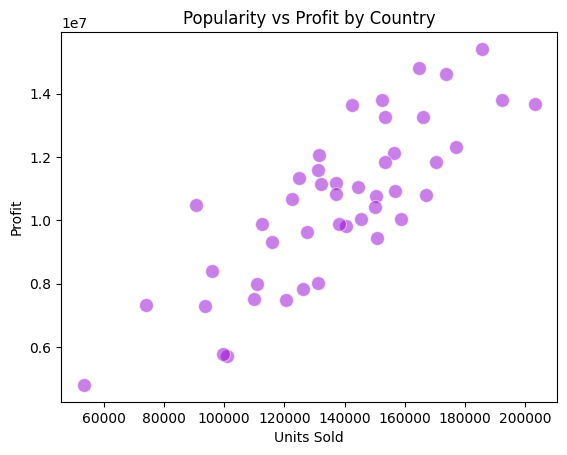

In [ ]:
sns.scatterplot(
    data=country_popularity_profit,
    x="units sold",
    y="profit",
    color="darkviolet",s=100,
    alpha=0.5
)
plt.title("Popularity vs Profit by Country")
plt.xlabel("Units Sold")
plt.ylabel("Profit")
plt.show()

Горізонтальна стовпчаста діаграма (Bar Chart) :"Топ-10 країн за кількістю проданих одиниць"

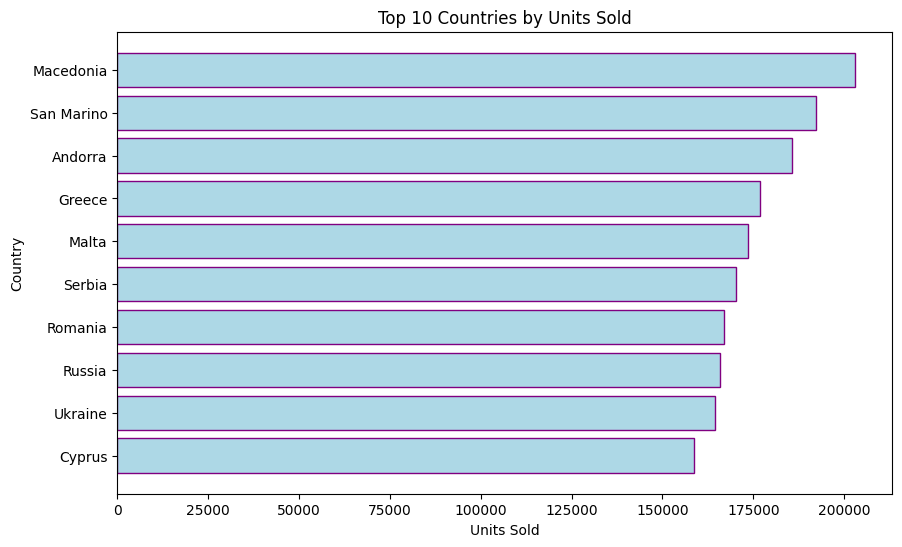

In [ ]:
top10_units_by_country = (
    sales_data[sales_data["country"].notna()]
    .groupby("country", as_index=False)["units sold"]
    .sum()
    .sort_values(by="units sold", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_units_by_country["country"],
    top10_units_by_country["units sold"],
    color="lightblue",
    edgecolor="purple"
)

plt.gca().invert_yaxis()

plt.title("Top 10 Countries by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Country")

plt.show()

Горізонтальна стовпчаста діаграма (Bar Chart) :"Топ-10 країн за прибутком"

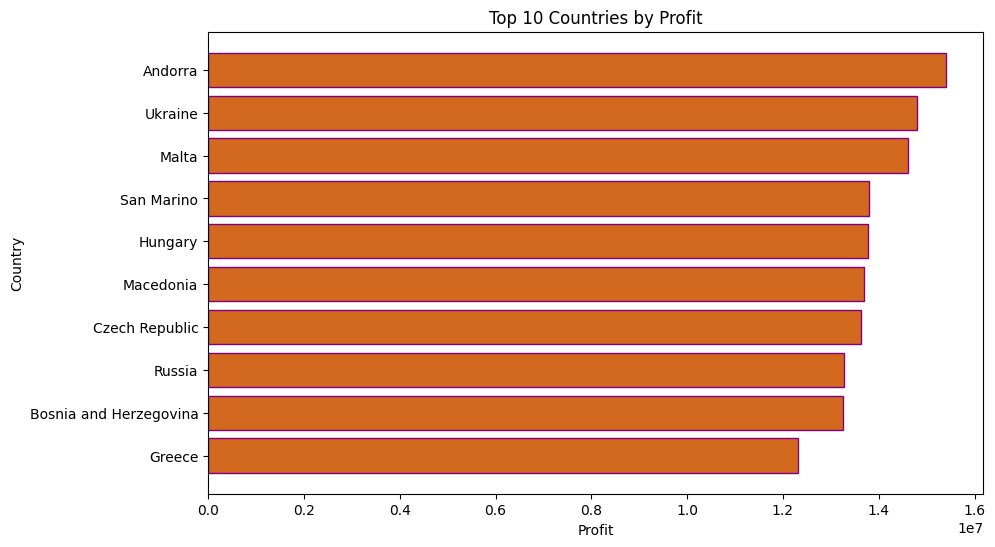

In [ ]:
top10_profit_by_country = (
    sales_data[sales_data["country"].notna()]
    .groupby("country", as_index=False)["profit"]
    .sum()
    .sort_values(by="profit", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_profit_by_country["country"],
    top10_profit_by_country["profit"],
    color="chocolate",
    edgecolor="purple"
)
plt.gca().invert_yaxis()

plt.title("Top 10 Countries by Profit")
plt.xlabel("Profit")
plt.ylabel("Country")

plt.show()

Горізонтальна стовпчаста діаграма (Bar Chart) :"Топ-10 країн з найдовшим середнім часом доставки":

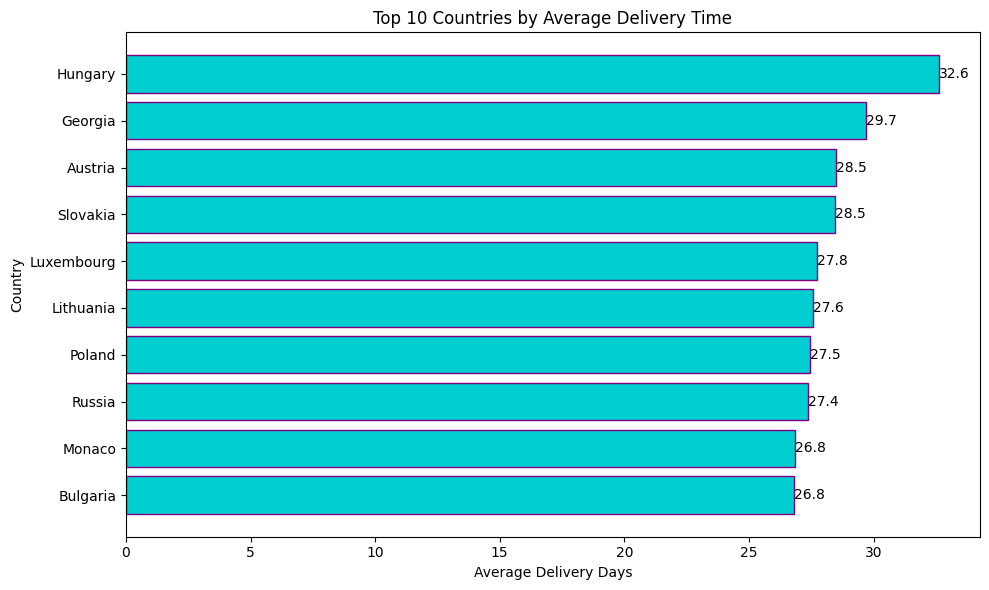

In [ ]:
top10_long_delivery_by_country = (
    sales_data[sales_data["country"].notna()]
    .groupby("country", as_index=False)["delivery days"]
    .mean()
    .sort_values(by="delivery days", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_long_delivery_by_country["country"],
    top10_long_delivery_by_country["delivery days"],
    color="darkturquoise",
    edgecolor="purple"
)
plt.gca().invert_yaxis()
for i, v in enumerate(top10_long_delivery_by_country["delivery days"]):
    plt.text(v, i, f"{v:.1f}", va="center")

plt.title("Top 10 Countries by Average Delivery Time")
plt.xlabel("Average Delivery Days")
plt.ylabel("Country")
plt.tight_layout()

plt.show()

Загальний прибуток по регіонах:

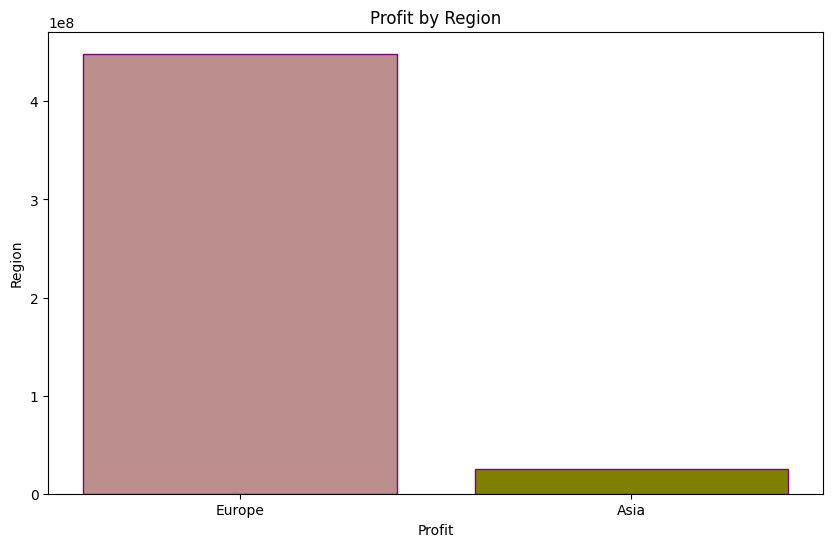

In [ ]:
total_profit_by_region = (
    sales_data[sales_data["region"].notna()]
    .groupby("region", as_index=False)["profit"]
    .sum()
    .sort_values(by="profit", ascending=False)

)

plt.figure(figsize=(10, 6))

plt.bar(
    total_profit_by_region["region"],
    total_profit_by_region["profit"],
    color=["rosybrown", "olive"],
    edgecolor="purple"
)
plt.title("Profit by Region")
plt.xlabel("Profit")
plt.ylabel("Region")

plt.show()

Діаграма розсіювання(Scatter Plot),яка показує зв’язок між середнім часом доставки та прибутком по країнах:

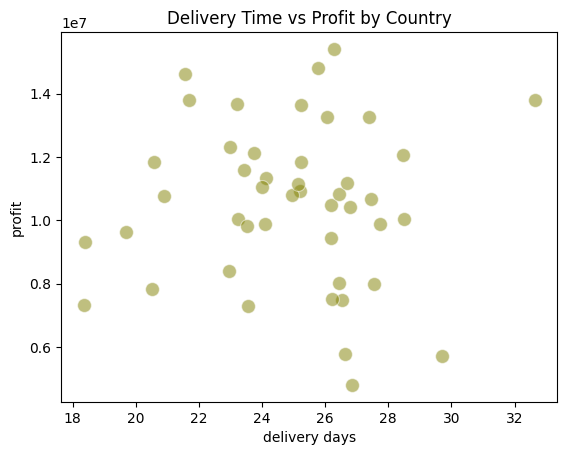

In [ ]:
sns.scatterplot(
    data=delivery_profit_country,
    x="delivery days",
    y="profit",s=100,
    color="olive",
    alpha=0.5
)
plt.title("Delivery Time vs Profit by Country")
plt.show()

Географічний аналіз продажів показав, що прибуток компанії нерівномірно розподілений між країнами та регіонами і значною мірою сконцентрований в Європі. Популярність ринків за обсягом продажів не завжди відповідає їхній прибутковості, що свідчить про різну ефективність роботи в окремих країнах. Аналіз логістичних показників не виявив сильної прямої залежності між середнім часом доставки та прибутком, однак країни з тривалішою доставкою рідше входять до числа найбільш прибуткових. Отримані результати підкреслюють необхідність комплексної оцінки ринків з урахуванням як фінансових, так і операційних показників для прийняття обґрунтованих бізнес-рішень.

**Продажі в розрізі каналів продажу (онлайн або офлайн):**

Розрахунок кількості проданих одиниць товару по кожному з каналів:

In [ ]:
units_sold_by_channel = sales_data.groupby("sales channel")["units sold"].sum()
units_sold_by_channel

,units sold
sales channel,
offline,3320363.0
online,3256161.0


Розрахунок прибутку в розрізі каналів продажу:

In [ ]:
profit_by_channel = sales_data.groupby("sales channel")["profit"].sum()
profit_by_channel

,profit
sales channel,
offline,2.534665e+08
online,2.479679e+08


Розрахунок прибутка по кожному замовленню в розрізі каналу продажу:

In [ ]:
profit_per_order_channel = sales_data.groupby(["sales channel", "order id"], as_index=False)["profit"].sum()
profit_per_order_channel

,sales channel,order id,profit
0,offline,100983083,176559.87
1,offline,103435266,119767.68
2,offline,103832662,502977.42
3,offline,104190576,66466.40
4,offline,104245078,17568.90
...,...,...,...
1323,online,989403665,395547.84
1324,online,990455090,1081553.98
1325,online,994406735,92487.96
1326,online,994504153,11408.94


Середній прибуток по кожному замовленню в розрізі каналу продажу:

In [ ]:
avg_profit_per_order_channel = (profit_per_order_channel.groupby("sales channel")["profit"].mean())
avg_profit_per_order_channel

,profit
sales channel,
offline,381152.659865
online,374008.959563


Стовпчаста діаграма(Bar Chart),яка показує загальний прибуток в розрізі каналів продажу:

/tmp/ipython-input-841617015.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


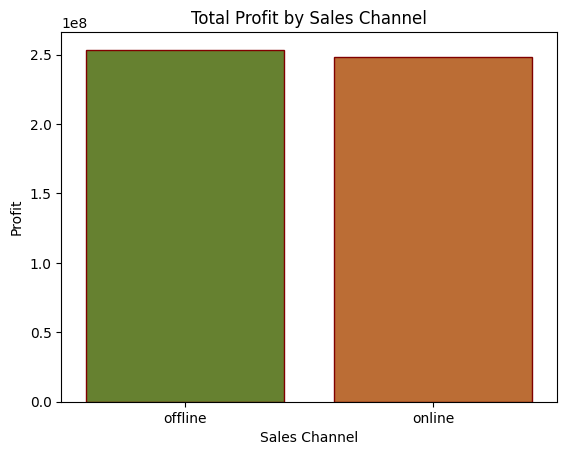

In [ ]:
sns.barplot(
    x=profit_by_channel.index,
    y=profit_by_channel.values,
    palette=["olivedrab", "chocolate"],
    edgecolor="maroon"
)
plt.title("Total Profit by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Profit")
plt.show()


Гістограма(Histogram),яка показує розподіл прибутку (profit) і порівнює його між двома каналами продажів: Online та Offline.

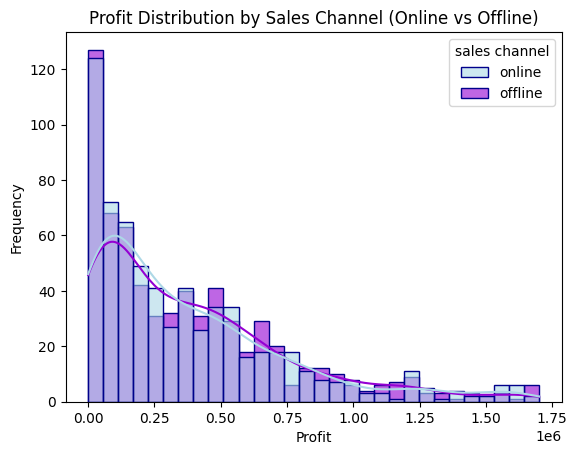

In [ ]:
sns.histplot(
    data=sales_data,
    x="profit",
    hue="sales channel",
    bins=30,
    kde=True,
     palette=["lightblue", "darkviolet"],
    edgecolor="darkblue",
    alpha=0.6
)

plt.title("Profit Distribution by Sales Channel (Online vs Offline)")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

Стовпчаста діаграма (barplot) показує скільки одиниць товару було продано в кожному каналі продажів:

/tmp/ipython-input-1573877455.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


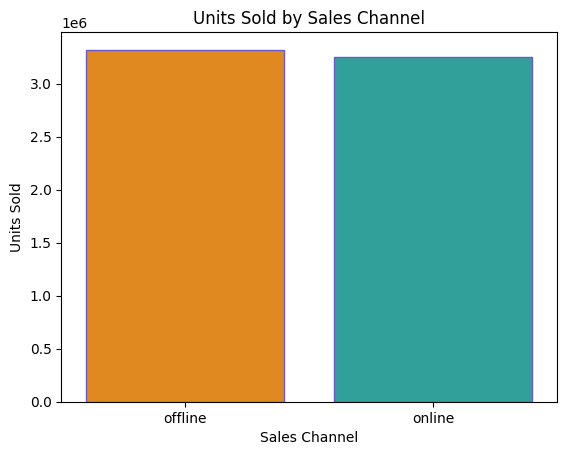

In [ ]:
sns.barplot(
    x=units_sold_by_channel.index,
    y=units_sold_by_channel.values,
    palette=["darkorange", "lightseagreen"],
    edgecolor="slateblue"
)
plt.title("Units Sold by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Units Sold")
plt.show()


KPI-картки: порівняння Online та Offline за двома ключовими метриками: загальний прибуток (Total Profit) та середній прибуток на замовлення (Avg Profit per Order):

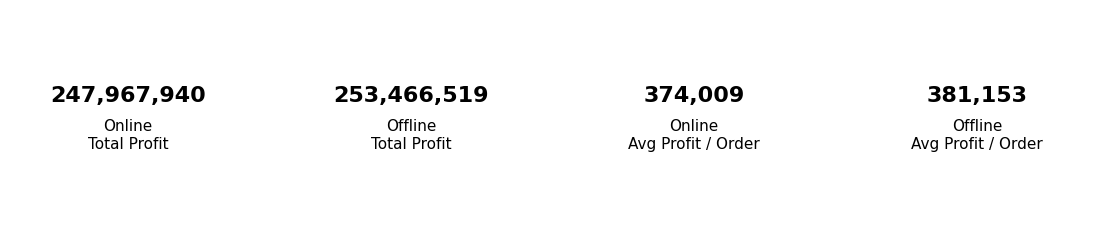

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax in axes:
    ax.axis("off")

kpis = [
    ("Online\nTotal Profit", profit_by_channel["online"]),
    ("Offline\nTotal Profit", profit_by_channel["offline"]),
    ("Online\nAvg Profit / Order", avg_profit_per_order_channel["online"]),
    ("Offline\nAvg Profit / Order", avg_profit_per_order_channel["offline"]),
]

for ax, (title, value) in zip(axes, kpis):
    ax.text(0.5, 0.6, f"{value:,.0f}", ha="center", fontsize=16, fontweight="bold")
    ax.text(0.5, 0.4, title, ha="center", fontsize=11)


Аналіз продажів у розрізі каналів показав, що онлайн та офлайн канали демонструють схожі результати за загальним прибутком та обсягом продажів, проте відрізняються за ефективністю одного замовлення. Офлайн-канал генерує дещо вищий загальний прибуток і має вищий середній прибуток на одне замовлення, що свідчить про більшу маржинальність або більший середній чек у цьому каналі. Водночас онлайн-канал забезпечує порівнянний обсяг продажів за кількістю проданих одиниць, що вказує на його важливу роль у формуванні загального попиту.

Гістограма розподілу прибутку замовлень показує, що для обох каналів характерна схожа структура з великою кількістю замовлень із невеликим прибутком та наявністю окремих високоприбуткових замовлень. Це означає, що онлайн-канал більше орієнтований на масштаб та кількість транзакцій, тоді як офлайн-канал є ефективнішим з точки зору прибутковості одного замовлення.

Узагальнюючи, можна зробити висновок, що обидва канали є стратегічно важливими для бізнесу, але виконують різні функції: онлайн-канал підтримує обсяги та охоплення, тоді як офлайн-канал забезпечує вищу фінансову ефективність на рівні окремих замовлень. Це свідчить про доцільність диференційованої стратегії розвитку каналів продажу з урахуванням їхніх сильних сторін.

**Інтервал часу між замовленням та його відвантаженням в розрізі категорій товарів**

Зведена таблиця статистики доставки по кожній категорії товарів delivery_stats_by_category,яка показує, в яких категоріях доставка швидша/повільніша, який розкид часу доставки (min–max), і скільки замовлень було в кожній категорії:

In [ ]:
delivery_stats_by_category = (
    sales_data
    .groupby("category")
    .agg(
        avg_delivery_days=("delivery days", "mean"),
        median_delivery_days=("delivery days", "median"),
        min_delivery_days=("delivery days", "min"),
        max_delivery_days=("delivery days", "max"),
        orders_count=("order id", "nunique")
    )
    .sort_values("avg_delivery_days")
)
delivery_stats_by_category

,avg_delivery_days,median_delivery_days,min_delivery_days,max_delivery_days,orders_count
category,,,,,
Personal Care,20.763158,20.5,0,50,114
Clothes,23.104762,21.0,0,50,105
Vegetables,23.491228,21.0,0,50,114
Household,23.938144,24.0,0,50,97
Beverages,24.123967,23.0,0,50,121
Fruits,24.419643,23.0,1,50,112
Snacks,25.543689,25.0,0,49,103
Meat,25.909091,25.0,0,50,110
Cosmetics,25.912281,28.0,0,50,114


Для аналізу часу доставки було розраховано середній, медіанний, мінімальний та максимальний інтервал доставки в розрізі категорій товарів, а також кількість замовлень у кожній категорії. Це дозволяє коректно порівнювати категорії та уникати висновків на основі недостатньої кількості даних.

Фільтрація таблиці delivery_stats_by_category,щоб залишились тільки ті категорії, де є достатньо даних — тобто мінімум 10 унікальних замовлень:

In [ ]:
filtered_delivery_stats = delivery_stats_by_category[
    delivery_stats_by_category["orders_count"] >= 10
]
filtered_delivery_stats

,avg_delivery_days,median_delivery_days,min_delivery_days,max_delivery_days,orders_count
category,,,,,
Personal Care,20.763158,20.5,0,50,114
Clothes,23.104762,21.0,0,50,105
Vegetables,23.491228,21.0,0,50,114
Household,23.938144,24.0,0,50,97
Beverages,24.123967,23.0,0,50,121
Fruits,24.419643,23.0,1,50,112
Snacks,25.543689,25.0,0,49,103
Meat,25.909091,25.0,0,50,110
Cosmetics,25.912281,28.0,0,50,114


Для забезпечення коректності аналізу з подальшого розгляду були виключені категорії з дуже малою кількістю замовлень(менш 10), де середні/медіанні значення доставки можуть бути нестабільними і нерепрезентативними.

Стовпчаста діаграма,яка показує середній час доставки товарів в розрізі категорій:

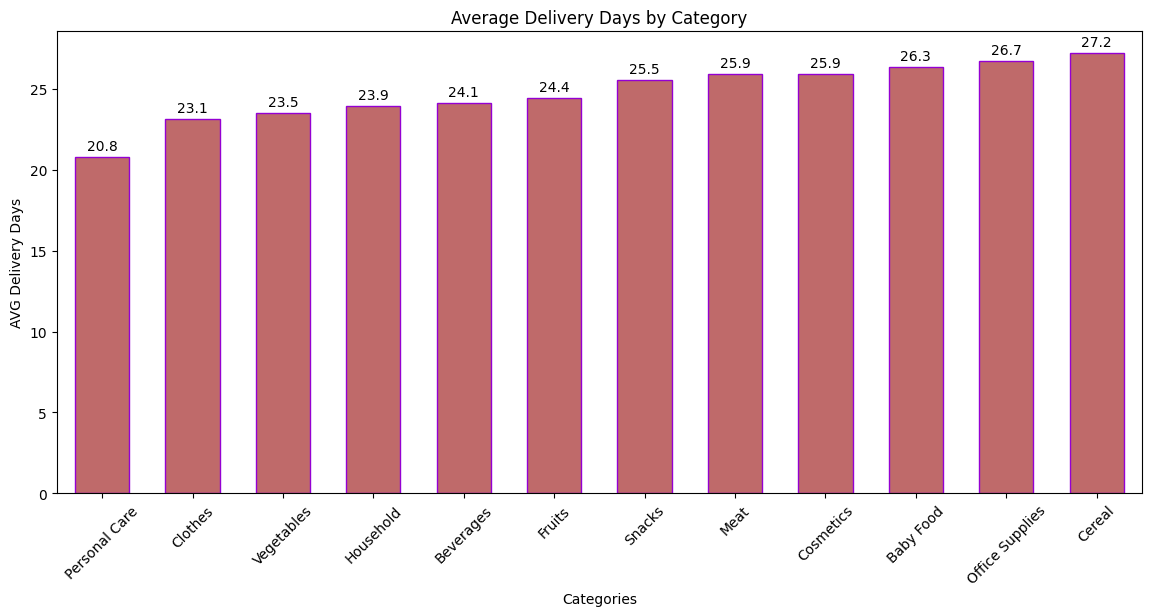

In [ ]:

plt.figure(figsize=(14, 6))
sns.barplot(
    data=filtered_delivery_stats.reset_index(),
    x="category",
    y="avg_delivery_days",
    color="indianred",
    edgecolor="darkviolet",
    width=0.6
)
for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.1f", padding=3)

plt.title("Average Delivery Days by Category")
plt.xlabel("Categories")
plt.ylabel("AVG Delivery Days")
plt.xticks(rotation=45)
plt.show()


Діаграма розмаху(boxplot), яка показує розподіл тривалості доставки (delivery days) для кожної категорії товарів,але лише для “валідних” категорій, де достатньо замовлень:

In [ ]:
valid_categories = filtered_delivery_stats.index

boxplot_data = sales_data[
    sales_data["category"].isin(valid_categories)
]


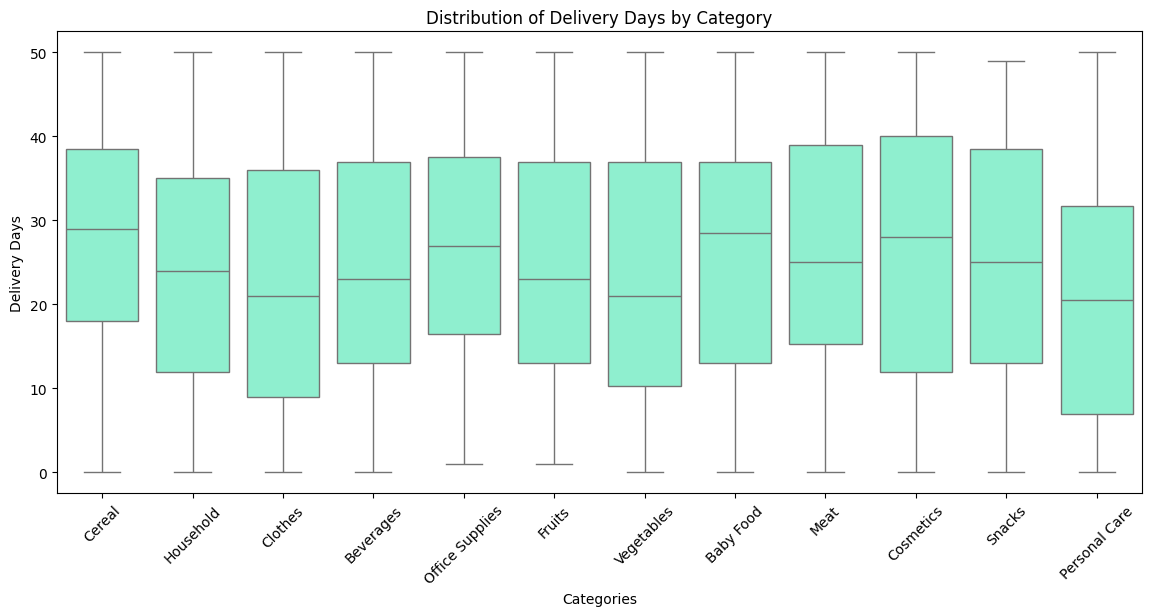

In [ ]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=boxplot_data,
    x="category",
    y="delivery days",
    color="aquamarine"
)

plt.title("Distribution of Delivery Days by Category")
plt.xlabel("Categories")
plt.ylabel("Delivery Days")
plt.xticks(rotation=45)
plt.show()


Аналіз середнього часу доставки в розрізі категорій товарів показав, що найшвидше доставляються товари категорії Personal Care, із середнім інтервалом близько 21 дня. Відносно швидку доставку також мають категорії Clothes та Vegetables.

Натомість найдовший середній час доставки спостерігається для категорій Cereal, Office Supplies та Baby Food, де середній інтервал перевищує 26–27 днів, що може свідчити про складніші логістичні процеси або довші ланцюги постачання.

Boxplot-аналіз розподілу часу доставки показав, що для більшості категорій характерний досить широкий розкид значень, що вказує на нестабільність доставки та наявність поодиноких затримок. Деякі категорії (наприклад, Personal Care та Clothes) демонструють більш стабільний розподіл, тоді як для категорій Cosmetics, Meat та Office Supplies спостерігається більша варіативність і наявність викидів.

Для аналізу були враховані лише категорії з достатньою кількістю замовлень, що забезпечує коректність порівняння та надійність висновків.

**Інтервал часу між замовленням та його відвантаженням в розрізі країн**

Копія таблиці sales_data,в якої всі пропуски замінюються на "Unknown", щоб не змінювати оригінальний датасет і безпечно підготувати дані для візуалізації:



In [ ]:
visual_country_data = sales_data.copy()
visual_country_data["country"] = visual_country_data["country"].fillna("Unknown")


Кількість замовлень по країнах:

In [ ]:
orders_count_by_country = (
    visual_country_data.groupby("country")["order id"].nunique()
)


Список країн, які можна “чесно” аналізувати + категорія "Unknown" :

In [ ]:
valid_countries = orders_count_by_country[orders_count_by_country >= 10].index
valid_countries = valid_countries.union(["Unknown"])



Фільтрація таблиці visual_country_data,за допомогою якої залишаються тільки ті рядки, де країна входить у список valid_countries:

In [ ]:
country_data = visual_country_data[visual_country_data["country"].isin(valid_countries)]
country_data


,order id,order date,order priority,sales channel,units sold,margin,delivery days,country,region,sub-region,category,profit
0,100640618,2014-10-08,M,online,650.0,88.59,10,Norway,Europe,Northern Europe,Cereal,57583.50
1,100983083,2016-08-11,C,offline,1993.0,88.59,0,Serbia,Europe,Southern Europe,Cereal,176559.87
2,101025998,2014-07-18,M,online,4693.0,165.73,24,Unknown,NaN,NaN,Household,777770.89
3,102230632,2017-05-13,L,online,1171.0,73.44,31,Montenegro,Europe,Southern Europe,Clothes,85998.24
4,103435266,2012-08-11,H,offline,7648.0,15.66,38,Serbia,Europe,Southern Europe,Beverages,119767.68
...,...,...,...,...,...,...,...,...,...,...,...,...
1323,994504153,2017-01-10,M,online,4734.0,2.41,3,Sweden,Europe,Northern Europe,Fruits,11408.94
1324,994978797,2014-12-05,H,offline,5192.0,15.66,28,Italy,Europe,Southern Europe,Beverages,81306.72
1325,996754205,2010-09-20,L,offline,574.0,95.86,2,Russia,Europe,Eastern Europe,Baby Food,55023.64
1326,998043382,2010-06-15,H,online,2070.0,173.87,18,Malta,Europe,Southern Europe,Cosmetics,359910.90


Таблиця статистики доставки по країнах (на основі вже відфільтрованих даних country_data),в якій сортуються країни так, щоб зверху були ті, де доставка в середньому найдовша:

In [ ]:
delivery_stats_by_country = (
    country_data
    .groupby("country")
    .agg(
        avg_delivery_days=("delivery days", "mean"),
        median_delivery_days=("delivery days", "median"),
        min_delivery_days=("delivery days", "min"),
        max_delivery_days=("delivery days", "max"),
        orders_count=("order id", "nunique")
    )
    .sort_values("avg_delivery_days", ascending=False)
)
delivery_stats_by_country.head(15)


,avg_delivery_days,median_delivery_days,min_delivery_days,max_delivery_days,orders_count
country,,,,,
Hungary,32.640000,36.0,2,50,25
Georgia,29.695652,32.0,7,47,23
Austria,28.500000,29.0,3,50,28
Slovakia,28.466667,32.0,3,50,30
Luxembourg,27.750000,30.5,0,48,28
Lithuania,27.560000,30.0,5,49,25
Poland,27.464286,27.0,6,50,28
Russia,27.375000,34.0,0,50,32
Monaco,26.846154,33.0,5,48,13


Стовпчаста діаграма(Bar Chart) з країнами, де найдовша середня доставка і  “Unknown”:


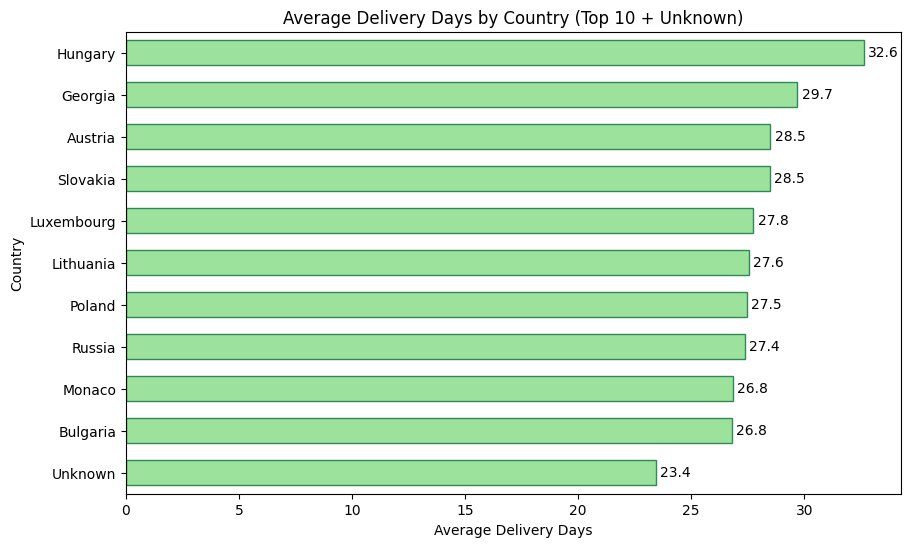

In [ ]:
top10 = delivery_stats_by_country.head(10).reset_index()

unknown_row = delivery_stats_by_country.loc[["Unknown"]].reset_index() \
    if "Unknown" in delivery_stats_by_country.index else None

plot_df = top10 if unknown_row is None else pd.concat([top10, unknown_row], ignore_index=True)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="avg_delivery_days",
    y="country",
    color="lightgreen",
    edgecolor="seagreen",
    width=0.6
)
for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.1f", padding=3)


plt.title("Average Delivery Days by Country (Top 10 + Unknown)")
plt.xlabel("Average Delivery Days")
plt.ylabel("Country")
plt.show()


Діаграма розмаху(boxplot), яка показує розподіл тривалості доставки (delivery days) по країнах — але лише для Top 10 країн за середньою доставкою + “Unknown”:

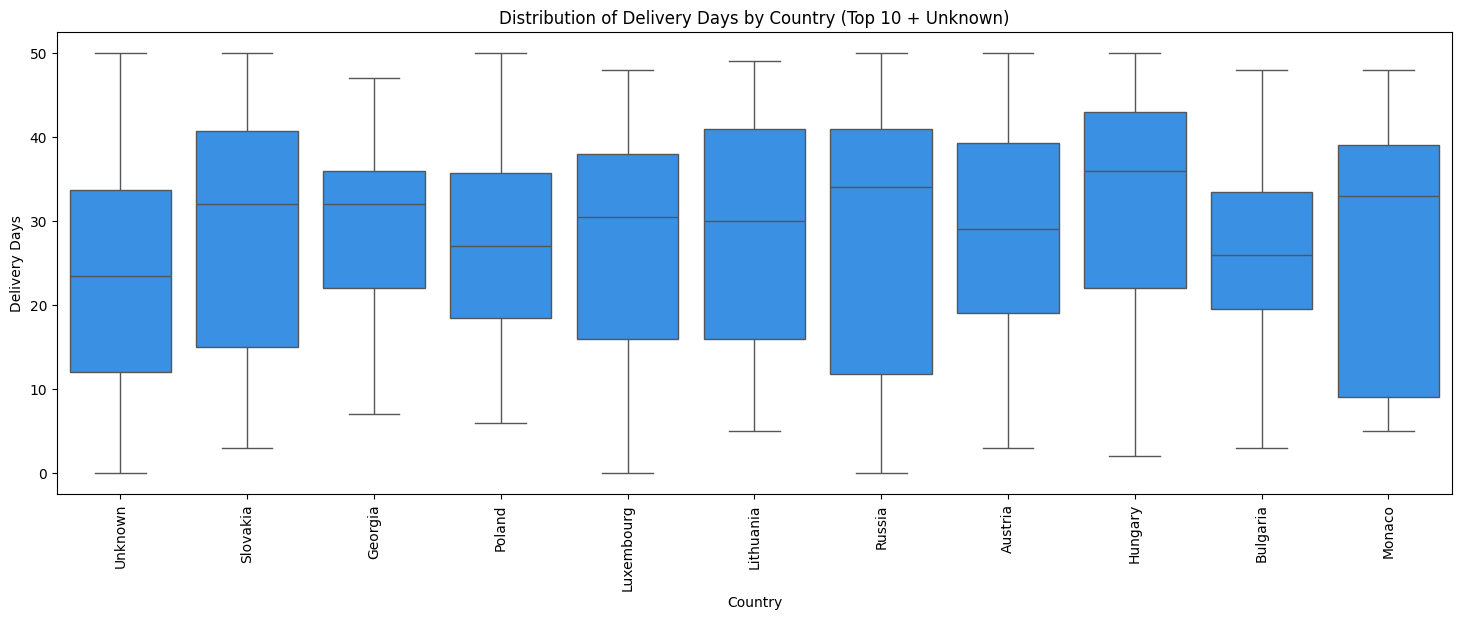

In [ ]:
plt.figure(figsize=(18, 6))
sns.boxplot(
    data=country_data[country_data["country"].isin(plot_df["country"])],
    x="country",
    y="delivery days",
    color="dodgerblue"
)

plt.title("Distribution of Delivery Days by Country (Top 10 + Unknown)")
plt.xlabel("Country")
plt.ylabel("Delivery Days")
plt.xticks(rotation=90)
plt.show()


Аналіз часу доставки в розрізі країн показав суттєві відмінності як за середніми значеннями, так і за розподілом показника. Найшвидша та найбільш стабільна доставка спостерігається у Croatia та United Kingdom, тоді як категорія Unknown та окремі країни (Liechtenstein, Greece) характеризуються довшим та більш нестабільним часом доставки. Це свідчить про нерівномірність логістичних процесів та можливі проблеми з якістю даних для частини замовлень.

**Інтервал часу між замовленням та його відвантаженням в розрізі регіонів**

Копія таблиці sales_data,в якої всі пропуски замінюються на "Unknown", щоб не змінювати оригінальний датасет і безпечно підготувати дані для візуалізації:

In [ ]:
visual_data = sales_data.copy()
visual_data["region"] = visual_data["region"].fillna("Unknown")

delivery_stats_by_region = (
    visual_data
    .groupby("region")
    .agg(
        avg_delivery_days=("delivery days", "mean"),
        median_delivery_days=("delivery days", "median"),
        min_delivery_days=("delivery days", "min"),
        max_delivery_days=("delivery days", "max"),
        orders_count=("order id", "nunique")
    )
    .sort_values("avg_delivery_days")
)
delivery_stats_by_region

,avg_delivery_days,median_delivery_days,min_delivery_days,max_delivery_days,orders_count
region,,,,,
Unknown,23.439024,23.5,0,50,82
Europe,24.790378,25.0,0,50,1164
Asia,26.085366,25.5,1,50,82


Стовпчаста діаграма, яка показує середній час доставки (у днях) для кожного регіону:

/tmp/ipython-input-3958070855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


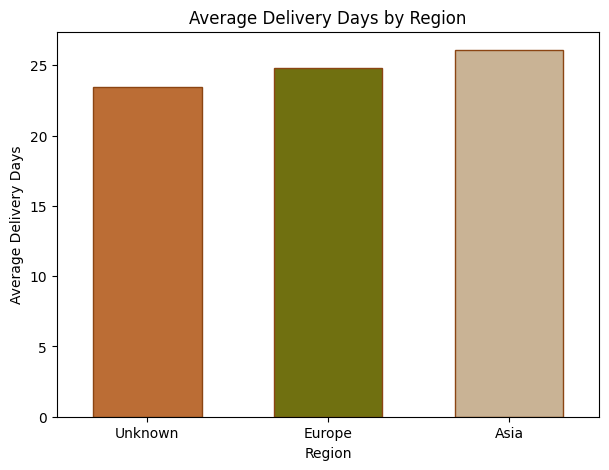

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=delivery_stats_by_region.reset_index(),
    x="region",
    y="avg_delivery_days",
    palette=["chocolate","olive",  "tan"],
    edgecolor="saddlebrown",
    width=0.6
)

plt.title("Average Delivery Days by Region")
plt.xlabel("Region")
plt.ylabel("Average Delivery Days")
plt.show()


Діаграма розмаху(boxplot), яка показує розподіл тривалості доставки (delivery days) у кожному регіоні:

/tmp/ipython-input-2751541998.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


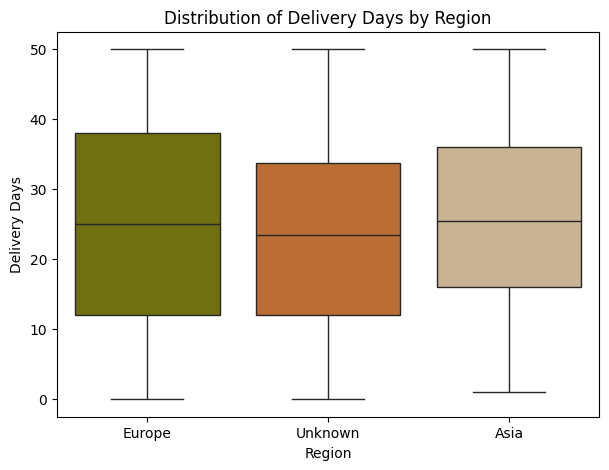

In [ ]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=visual_data,
    x="region",
    y="delivery days",
    palette=["olive", "chocolate", "tan"]
)

plt.title("Distribution of Delivery Days by Region")
plt.xlabel("Region")
plt.ylabel("Delivery Days")
plt.show()


Аналіз середнього часу доставки в розрізі регіонів показав, що найдовший середній інтервал доставки спостерігається в регіоні Asia, де середній час доставки становить близько 26 днів. Регіон Europe має дещо коротший середній час доставки (приблизно 25 днів), тоді як для замовлень із невизначеним регіоном (Unknown) середній показник є найнижчим (близько 23–24 днів).

Boxplot-аналіз розподілу часу доставки свідчить про те, що в усіх регіонах спостерігається значна варіативність delivery days, включаючи наявність викидів. Це означає, що навіть у регіонах із відносно помірним середнім часом доставки можуть виникати як дуже швидкі, так і значно затримані замовлення.

Для регіону Europe, який має найбільшу кількість замовлень, характерний широкий міжквартильний діапазон, що може вказувати на різноманітність логістичних маршрутів та умов доставки всередині регіону. Регіон Asia, попри меншу кількість замовлень, демонструє вищу медіану та загалом довший час доставки, що може бути пов’язано з більшими відстанями або складнішою логістикою.

Категорія Unknown має меншу кількість спостережень, тому результати для цього регіону слід інтерпретувати з обережністю, однак її включення дозволяє зберегти повноту вибірки та не втрачати дані з пропущеною географією.

**Залежність прибутка від часу, необхідного на відвантаження товару**

Перевірка даних:

In [ ]:
sales_data[["delivery days", "profit"]].dtypes


,0
delivery days,int64
profit,float64


In [ ]:
sales_data[["delivery days", "profit"]].isna().sum()


,0
delivery days,0
profit,0


In [ ]:
sales_data["delivery days"].mean()
sales_data["profit"].mean()



np.float64(377586.1890060241)

Точковий графік (scatter plot),який показує зв’язок між тривалістю доставки та прибутком в розрізі регіонів:

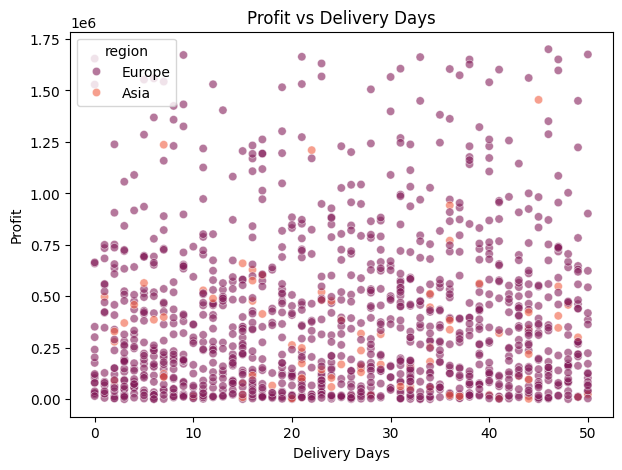

In [ ]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=sales_data,
    x="delivery days",
    y="profit",
    hue="region",
    palette="rocket",
    alpha=0.6
)

plt.title("Profit vs Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Profit")
plt.show()


Аналіз scatter plot Profit vs Delivery Days з розподілом за регіонами показує, що чіткої залежності між часом відвантаження та прибутком не спостерігається. Точки на графіку розташовані хаотично по всьому діапазону delivery days, що свідчить про відсутність вираженого тренду як зростання, так і зменшення прибутку зі збільшенням часу доставки.

Для регіону Europe, який має найбільшу кількість спостережень, прибуток варіюється в широкому діапазоні при будь-якому значенні delivery days. Це означає, що як короткі, так і довші інтервали відвантаження можуть бути пов’язані як з низьким, так і з високим прибутком.

Регіон Asia представлений меншою кількістю замовлень, однак його точки значною мірою перекриваються з розподілом для Europe. Це свідчить про те, що поведінка прибутку залежно від часу доставки є подібною в обох регіонах, і регіональний фактор не формує окремого тренду в цій залежності.

Загалом, отримані результати дозволяють зробити висновок, що час відвантаження не є визначальним фактором прибутковості замовлення. На прибуток, ймовірно, значно сильніше впливають інші змінні, такі як тип товару, обсяг замовлення або цінова політика.

**Динаміка продажів у часі**

Створення нової колонки order_month, у якій для кожного замовлення буде записаний місяць замовлення (у вигляді дати першого дня місяця):

In [ ]:
sales_data["order_month"] = sales_data["order date"].dt.to_period("M").dt.to_timestamp()
sales_data["order_month"]


,order_month
0,2014-10-01
1,2016-08-01
2,2014-07-01
3,2017-05-01
4,2012-08-01
...,...
1323,2017-01-01
1324,2014-12-01
1325,2010-09-01
1326,2010-06-01


Лінійний графік(Line Plot) динаміки загального прибутку по місяцях:

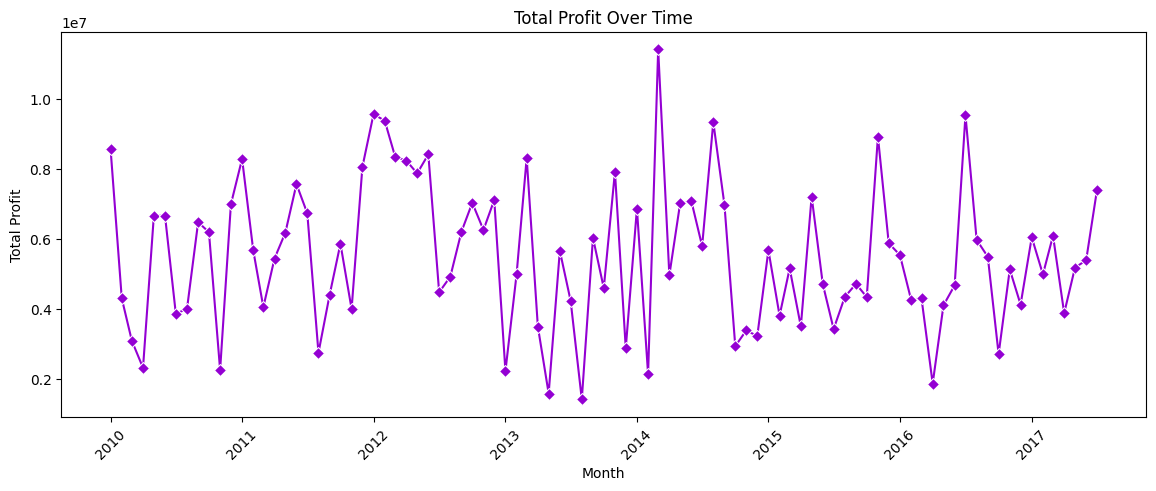

In [ ]:
profit_over_time = (
    sales_data
    .groupby("order_month", as_index=False)["profit"]
    .sum()
)

plt.figure(figsize=(14, 5))
sns.lineplot(
    data=profit_over_time,
    x="order_month",
    y="profit",
    color="darkviolet",
    marker="D"
)

plt.title("Total Profit Over Time")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()


Підготовка даних, щоб подивитися прибуток по категоріях у розрізі місяців (матриця “категорія × місяць”):

In [ ]:
category_month_profit = (
    sales_data
    .groupby(["order_month", "category"], as_index=False)["profit"]
    .sum()
)

pivot_cat = category_month_profit.pivot(
    index="category",
    columns="order_month",
    values="profit"
).fillna(0)


Теплова карта (Heatmap), яка показує прибуток по категоріях у розрізі місяців:

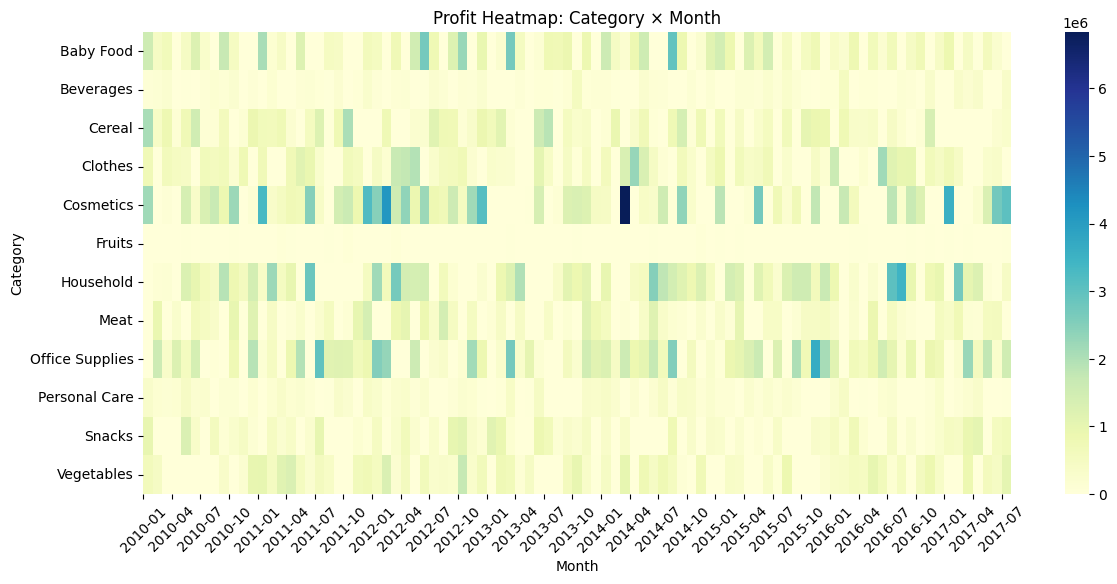

In [ ]:
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_cat, cmap="YlGnBu")

plt.title("Profit Heatmap: Category × Month")
plt.xlabel("Month")
plt.ylabel("Category")

plt.xticks(
    ticks=range(0, len(pivot_cat.columns), 3),
    labels=[pivot_cat.columns[i].strftime("%Y-%m") for i in range(0, len(pivot_cat.columns), 3)],
    rotation=45
)

plt.show()


ТОП-5 країн за загальним прибутком:

In [ ]:
top_countries = (
    sales_data
    .groupby("country")["profit"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)


Порівняння трендів прибутку по топ-5 країнах у часі, зі згладжуванням, щоб краще бачити загальну динаміку (зростання/падіння/піки) без “шуму” окремих місяців:

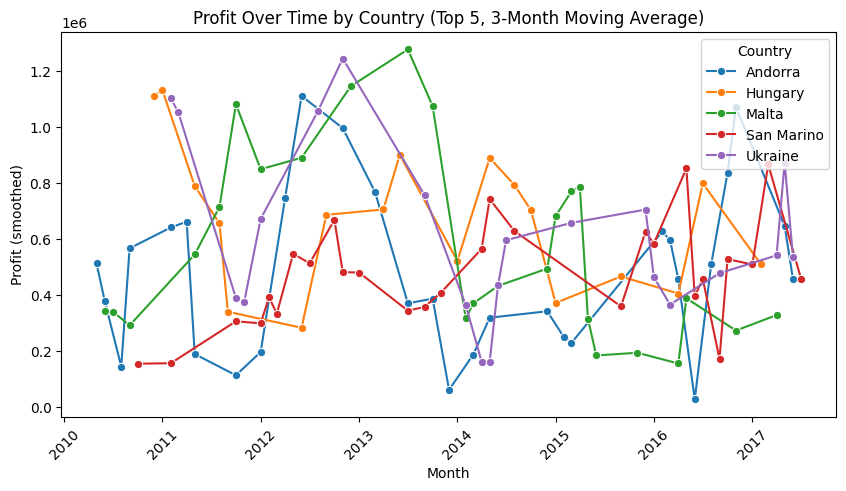

In [ ]:
country_time = (
    sales_data[sales_data["country"].isin(top_countries)]
    .groupby(["order_month", "country"], as_index=False)["profit"]
    .sum()
    .sort_values("order_month")
)

country_time["profit_3m_ma"] = (
    country_time
    .groupby("country")["profit"]
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=country_time,
    x="order_month",
    y="profit_3m_ma",
    hue="country",
    marker="o"
)

plt.title("Profit Over Time by Country (Top 5, 3-Month Moving Average)")
plt.xlabel("Month")
plt.ylabel("Profit (smoothed)")
plt.xticks(rotation=45)
plt.legend(title="Country")
plt.show()


Створення новї колонки order_month для visual_data, де кожна дата замовлення перетворюється на місяць (перший день відповідного місяця):

In [ ]:
visual_data["order_month"] = visual_data["order date"].dt.to_period("M").dt.to_timestamp()


Лінійний графік(Line Plot) динаміки прибутку по місяцях у розрізі регіонів:

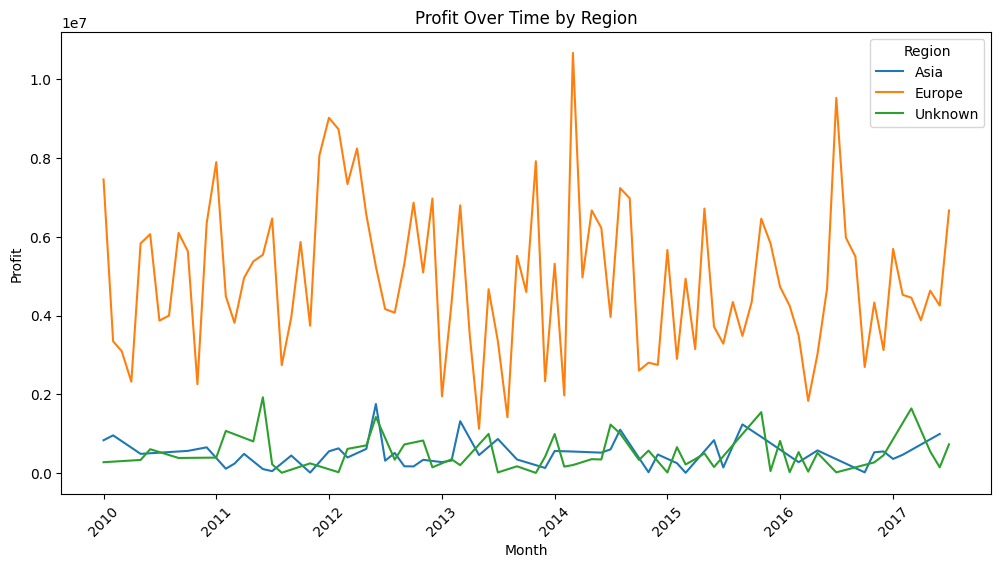

In [ ]:

profit_by_region_time = (
    visual_data
    .groupby(["order_month", "region"], as_index=False)["profit"]
    .sum()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=profit_by_region_time,
    x="order_month",
    y="profit",
    hue="region"
)

plt.title("Profit Over Time by Region")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.legend(title="Region")
plt.show()




За результатами аналізу динаміки прибутку у часі спостерігається висока волатильність: значення суттєво коливаються від місяця до місяця, формуючи окремі пікові періоди та спадання. У розрізі регіонів Europe стабільно забезпечує найбільшу частку прибутку та саме вона формує основні піки, тоді як Asia має значно менший внесок і коливається на нижчому рівні. Категорійний аналіз показав концентрацію прибутку в окремих групах товарів: деякі категорії формують регулярні або різкі “сплески”, тоді як інші демонструють низькі й відносно рівні значення протягом періоду. У розрізі країн навіть серед топ-ринків прибутковість нерівномірна: лідерство змінюється в часі, що вказує на залежність від окремих місяців і подій. Також присутність групи Unknown свідчить про частину записів із невизначеною географією, що варто врахувати як обмеження якості даних під час інтерпретації результатів.

**Аналіз продажів товарів за днями тижня**

Додавання стовпця до sales_data, який показує в який день тижня було зроблене замовлення:

In [ ]:
sales_data["weekday"] = sales_data["order date"].dt.day_name()
sales_data[["order date", "weekday"]].head(7)


,order date,weekday
0,2014-10-08,Wednesday
1,2016-08-11,Thursday
2,2014-07-18,Friday
3,2017-05-13,Saturday
4,2012-08-11,Saturday
5,2015-03-15,Sunday
6,2013-04-20,Saturday


In [ ]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]


Загальний прибуток по днях тижня:

In [ ]:
profit_by_weekday = (
    sales_data
    .groupby("weekday", as_index=False)["profit"]
    .sum()
)

profit_by_weekday["weekday"] = pd.Categorical(
    profit_by_weekday["weekday"],
    categories=weekday_order,
    ordered=True
)

profit_by_weekday = profit_by_weekday.sort_values("weekday")
profit_by_weekday


,weekday,profit
1,Monday,75790330.12
5,Tuesday,65637400.07
6,Wednesday,72323843.38
4,Thursday,64325663.17
0,Friday,79234529.04
2,Saturday,71435860.49
3,Sunday,72686832.73


Стовпчаста діаграма,яка показує загальний прибуток по днях тижня:

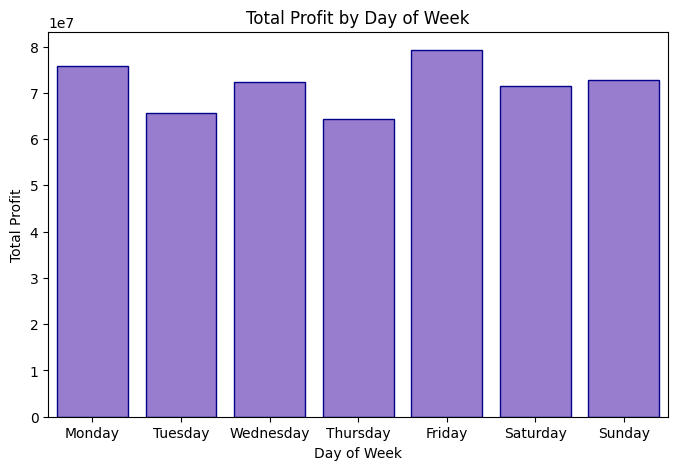

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=profit_by_weekday,
    x="weekday",
    y="profit",
    color="mediumpurple",
    edgecolor="darkblue"
)
plt.title("Total Profit by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Profit")
plt.show()


Прибуток у розрізі “день тижня × категорія товару”:

In [ ]:
category_weekday_profit = (
    sales_data
    .groupby(["weekday", "category"], as_index=False)["profit"]
    .sum()
)

category_weekday_profit["weekday"] = pd.Categorical(
    category_weekday_profit["weekday"],
    categories=weekday_order,
    ordered=True
)

category_weekday_profit = category_weekday_profit.sort_values("weekday")
category_weekday_profit


,weekday,category,profit
23,Monday,Vegetables,6541656.86
22,Monday,Snacks,5950488.24
21,Monday,Personal Care,1672228.74
20,Monday,Office Supplies,11860051.25
19,Monday,Meat,5742193.60
...,...,...,...
43,Sunday,Meat,3177059.60
44,Sunday,Office Supplies,12921561.25
45,Sunday,Personal Care,2101030.40
47,Sunday,Vegetables,7196756.87


Теплова карта (heatmap), яка показує прибуток по категоріях у розрізі днів тижня:

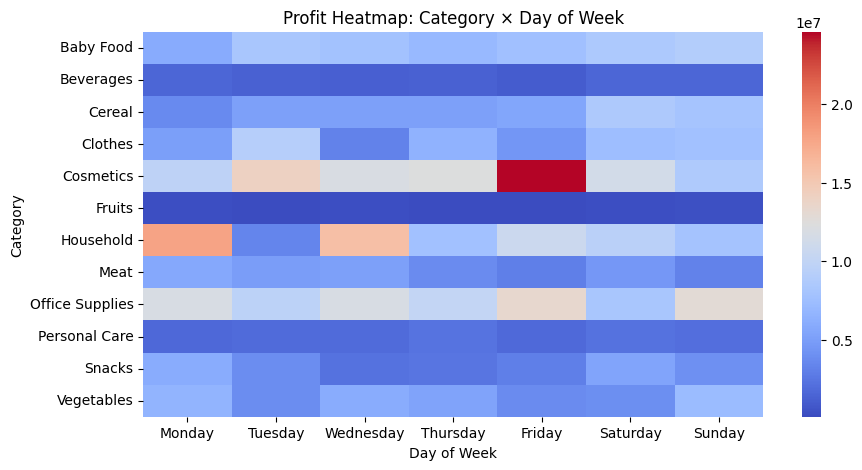

In [ ]:
pivot_weekday_category = category_weekday_profit.pivot(
    index="category",
    columns="weekday",
    values="profit"
).fillna(0)

plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_weekday_category,
    cmap="coolwarm"
)
plt.title("Profit Heatmap: Category × Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Category")
plt.show()


Кількість замовлень по днях тижня:


In [ ]:
orders_by_weekday = (
    sales_data
    .groupby("weekday")["order id"]
    .nunique()
    .reindex(weekday_order)   # щоб був порядок Monday→Sunday
)

orders_by_weekday


,order id
weekday,
Monday,201
Tuesday,182
Wednesday,194
Thursday,167
Friday,176
Saturday,201
Sunday,207


Стовпчаста діаграма(Bar Chart),яка показує кількість замовлень по днях тижня:

/tmp/ipython-input-1222724005.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


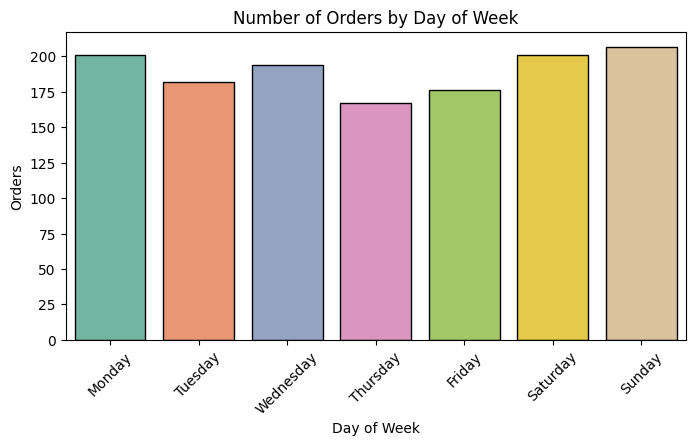

In [ ]:
df_plot = orders_by_weekday.reset_index()
df_plot.columns = ["weekday", "orders_count"]

plt.figure(figsize=(8,4))
sns.barplot(
    data=df_plot,
    x="weekday",
    y="orders_count",
    order=weekday_order,
    palette="Set2",
    edgecolor="black"
)
plt.xticks(rotation=45)
plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Orders")
plt.show()

Середній прибуток на замовлення по днях тижня:

In [ ]:

order_profit_weekday = (
    sales_data
    .groupby("order id")
    .agg(
        profit=("profit", "sum"),
        weekday=("weekday", "first")
    )
    .reset_index()
)

avg_profit_per_order_by_weekday = (
    order_profit_weekday
    .groupby("weekday", as_index=False)["profit"]
    .mean()
)

avg_profit_per_order_by_weekday["weekday"] = pd.Categorical(
    avg_profit_per_order_by_weekday["weekday"],
    categories=weekday_order,
    ordered=True
)
avg_profit_per_order_by_weekday = avg_profit_per_order_by_weekday.sort_values("weekday")

avg_profit_per_order_by_weekday


,weekday,profit
1,Monday,377066.319005
5,Tuesday,360645.055330
6,Wednesday,372803.316392
4,Thursday,385183.611796
0,Friday,450196.187727
2,Saturday,355402.290995
3,Sunday,351144.119469


Стовпчаста діаграма(Bar Chart),яка показує  середній прибуток на замовлення по днях тижня:

/tmp/ipython-input-2377606578.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


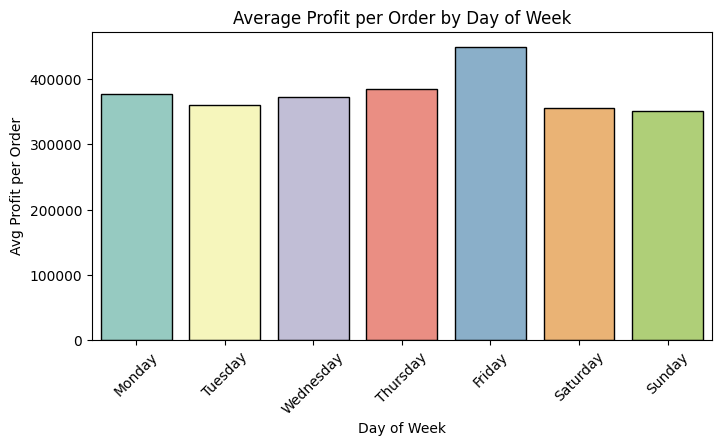

In [ ]:
weekday_palette = dict(zip(weekday_order, sns.color_palette("Set3", 7)))

plt.figure(figsize=(8,4))
sns.barplot(
    data=avg_profit_per_order_by_weekday,
    x="weekday",
    y="profit",
    order=weekday_order,
    palette=weekday_palette,
    edgecolor="black"
)
plt.title("Average Profit per Order by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Avg Profit per Order")
plt.xticks(rotation=45)
plt.show()

Аналіз продажів за днями тижня показує помірну нерівномірність попиту: найбільша кількість замовлень припадає на вихідні (субота–неділя) та понеділок, тоді як четвер і частково п’ятниця мають менше замовлень. Водночас за показником середнього прибутку на замовлення лідирує п’ятниця, тобто у цей день замовлень може бути не найбільше, але вони більш “дорогі/прибуткові”. Теплова карта “категорія × день тижня” підтверджує, що поведінка відрізняється між товарними групами: окремі категорії мають чіткі піки у конкретні дні (найбільш помітно — Cosmetics у п’ятницю), тоді як інші розподілені більш рівномірно. Отже, частину товарів можна вважати сезонними в межах тижня (тижнева сезонність).

#**Висновки**:                                                                     
У рамках проєкту було проаналізовано дані продажів на основі фактової таблиці events, що містить інформацію про замовлення (дати, канал продажів, обсяг, ціна та собівартість), а також двох довідників — countries (географія) та products (категорії товарів). Дані були інтегровані через зв’язки Country Code ↔ alpha-3 і Product ID ↔ id, а для збереження повноти продажів застосовано підхід із LEFT JOIN, що дозволяє враховувати всі замовлення навіть за наявності пропусків у географічних атрибутах. У результаті сформовано фінальний датасет sales_data, з якого прибрано технічні ідентифікатори та проміжні поля, залишивши лише бізнес-релевантні показники; окремо розраховано ключові метрики profit/margin та логістичний показник delivery_days.

Під час очищення даних виявлено і оброблено пропуски та потенційні проблеми якості. Для Antarctica пропуски в region і sub-region є очікуваними, тому їх замінено на “No region/No sub-region”, щоб уникнути помилок групування. Для Namibia відновлено alpha-2 відповідно до ISO-стандарту, а в events зафіксовано 82 записи без Country Code (близько 6%), які неможливо коректно відновити; ці пропуски збережено, аби не втрачати продажі, але їх потрібно враховувати як обмеження при геоаналізі. Невелику кількість пропусків у Units Sold (2 записи) вилучено, оскільки ця колонка критична для розрахунків, а частка пропусків незначна. Також виконано нормалізацію текстових полів (пробіли/регістр), приведення дат до datetime та перевірку логіки дат: від’ємних інтервалів доставки не виявлено, а максимальний delivery_days (до 50 днів) виглядає реалістично і може пояснюватися логістичними затримками.

Аналіз продажів за категоріями показав, що прибутковість формують не лише “популярні” товари. Найбільший вклад у прибуток дають Cosmetics, Office Supplies та Household — ці категорії фактично є драйверами фінансового результату. Водночас Beverages та Fruits демонструють високі обсяги продажів у штуках, але відносно низький прибуток, що з бізнес-точки зору найчастіше означає низьку маржу або вищу собівартість/ціновий тиск. Тому опора лише на Units Sold може приводити до хибних рішень: для управління асортиментом важливо паралельно контролювати маржинальність, а не тільки “попит у штуках”.

Географічний зріз виявив концентрацію прибутку в Європі, яка формує основну частину фінансового результату, тоді як інші регіони мають допоміжний внесок. Важливий висновок для бізнесу: популярність ринку (високі Units Sold) не гарантує ефективності (високого profit), отже для пріоритезації країн потрібна комплексна оцінка — “обсяг + прибуток + логістика”. З точки зору операцій, явної прямої залежності між середнім часом доставки та прибутком не зафіксовано, однак країни з довшими доставками рідше входять до числа найбільш прибуткових; це може означати, що повільніша логістика знижує конкурентність або збільшує непрямі витрати.

У розрізі каналів продажу Online та Offline демонструють близькі значення за загальним прибутком та обсягом продажів, але різняться за ефективністю одного замовлення. Офлайн канал має дещо вищий загальний прибуток і вищий середній прибуток на замовлення, що може свідчити про більший середній чек, кращу маржинальність або інший товарний мікс. Онлайн при цьому забезпечує порівнянний масштаб за кількістю проданих одиниць, тобто працює як канал охоплення і обсягу. Така картина підказує диференційовану стратегію: онлайн — для масштабування та залучення, офлайн — для підсилення прибутковості й продажів із вищою маржею.

Логістичний аналіз показав, що швидкість доставки суттєво відрізняється між категоріями та країнами. Серед категорій найшвидше доставляються Personal Care (приблизно 21 день у середньому), тоді як Cereal, Office Supplies, Baby Food мають довші інтервали (понад 26–27 днів), що може бути пов’язано з особливостями постачання або складністю логістичного ланцюга. Розподіли (boxplot) свідчать про значну варіативність доставки й наявність поодиноких затримок у багатьох категоріях, тобто операційна стабільність — зона для покращення. На рівні країн видно, що частина напрямків має більш стабільну і швидку доставку, а Unknown та окремі країни демонструють довші й нестабільніші інтервали, що одночасно вказує і на логістичну нерівномірність, і на потребу покращення якості геоданих.

Перевірка гіпотези “прибуток залежить від часу доставки” показала відсутність чіткого тренду: при будь-яких значеннях delivery_days зустрічаються як високоприбуткові, так і низькоприбуткові замовлення, особливо в Europe, де найбільше спостережень. Це означає, що час доставки сам по собі не є визначальним драйвером прибутку, а на фінансовий результат сильніше впливають тип товару, обсяг, маржа і, ймовірно, цінові умови. Водночас логістика залишається важливою з точки зору клієнтського досвіду та стабільності сервісу, тому скорочення варіативності доставки може мати непрямий позитивний ефект.

Аналіз динаміки у часі показав високу волатильність прибутку без стабільного довгострокового тренду зростання. Основні піки формуються переважно за рахунок Europe, а на рівні категорій і країн спостерігаються нерівномірні сплески без чіткої сезонності, що натякає на вплив разових великих замовлень або зовнішніх факторів. Додатково аналіз за днями тижня показав тижневий патерн: найбільше замовлень припадає на вихідні та понеділок, тоді як п’ятниця вирізняється найвищим середнім прибутком на замовлення, тобто в цей день покупки можуть бути “ціннішими”. Теплова карта “категорія × день тижня” підтверджує різну поведінку товарних груп і наявність тижневої сезонності: окремі категорії (особливо Cosmetics) мають виражені піки у конкретні дні, тоді як інші залишаються більш рівномірними.

З бізнес-точки зору отримані результати підказують кілька стратегічних акцентів: зосередити увагу на високоприбуткових категоріях (Cosmetics/Office Supplies/Household) і паралельно переглянути маржинальність “об’ємних, але слабоприбуткових” категорій (Beverages/Fruits), оскільки високі продажі в штуках не завжди дають фінансовий ефект. Доцільно підтримувати домінуючі ринки Європи, але оцінювати країни комплексно — через поєднання прибутковості, обсягів та логістичних метрик, щоб уникати “популярних, але неефективних” ринків. Для каналів продажу логічною є модель, де онлайн використовується для масштабу та охоплення, а офлайн — для максимізації прибутковості на рівні замовлення. Нарешті, для коректності управлінських висновків важливо зменшити частку “Unknown” у географії (якість заповнення Country Code/region), оскільки це напряму впливає на точність рішень щодо ринків і логістики.